# Machine Learning Work

- José: Ridge
- Paulino: Random Forest
- Al-Samir: Linear Regression

In [416]:
import copy
import warnings


from dataclasses import dataclass
from pathlib import Path
from typing import Any, Sequence
from functools import partial


import numpy as np
import pandas as pd
import seaborn as sns
import scipy.stats as stats
import matplotlib.cm as cm
import matplotlib.pyplot as plt


from skopt import BayesSearchCV
from sklearn.base import BaseEstimator
from sklearn.cluster import KMeans
from sklearn.linear_model import Ridge, LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import (
    train_test_split,
    BaseCrossValidator,
    cross_val_score,
)
from sklearn.neighbors import LocalOutlierFactor
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    r2_score,
    root_mean_squared_error,
    mean_absolute_error,
    silhouette_score,
)

In [417]:
RANDOM_SEED = 42
TEST_RATIO = 0.2
CORRELATION_THRESHOLD = 0.1
POI_COUNT_EMPTINESS_THRESHOLD = 0.5
MAX_CLUSTERS = 40

DATA_BASE_PATH = Path("./data")
POI_DATA_BASE_PATH = Path("./poi-data")
TARGET = "price"

In [418]:
rent_path = DATA_BASE_PATH / "apartments_for_rent_classified_10K.csv"
poi_count_path = (
    POI_DATA_BASE_PATH / "poi-data-count-5d44b231d67f516b837067ff178d5c01.parquet"
)

In [419]:
rent = pd.read_csv(
    rent_path,
    sep=";",
    encoding="latin1",
    dtype={"id": str, "price": float, "square_feet": float},
)
rent.head()

,id,category,title,body,amenities,bathrooms,bedrooms,currency,fee,has_photo,...,price_display,price_type,square_feet,address,cityname,state,latitude,longitude,source,time
0,5668626895,housing/rent/apartment,"Studio apartment 2nd St NE, Uhland Terrace NE,...","This unit is located at second St NE, Uhland T...",NaN,NaN,0.0,USD,No,Thumbnail,...,$790,Monthly,101.0,NaN,Washington,DC,38.9057,-76.9861,RentLingo,1577359415
1,5664597177,housing/rent/apartment,Studio apartment 814 Schutte Road,"This unit is located at 814 Schutte Road, Evan...",NaN,NaN,1.0,USD,No,Thumbnail,...,$425,Monthly,106.0,814 Schutte Rd,Evansville,IN,37.9680,-87.6621,RentLingo,1577017063
2,5668626833,housing/rent/apartment,"Studio apartment N Scott St, 14th St N, Arling...","This unit is located at N Scott St, 14th St N,...",NaN,1.0,0.0,USD,No,Thumbnail,...,"$1,390",Monthly,107.0,NaN,Arlington,VA,38.8910,-77.0816,RentLingo,1577359410
3,5659918074,housing/rent/apartment,Studio apartment 1717 12th Ave,"This unit is located at 1717 12th Ave, Seattle...",NaN,1.0,0.0,USD,No,Thumbnail,...,$925,Monthly,116.0,1717 12th Avenue,Seattle,WA,47.6160,-122.3275,RentLingo,1576667743
4,5668626759,housing/rent/apartment,"Studio apartment Washington Blvd, N Cleveland ...","This unit is located at Washington Blvd, N Cle...",NaN,NaN,0.0,USD,No,Thumbnail,...,$880,Monthly,125.0,NaN,Arlington,VA,38.8738,-77.1055,RentLingo,1577359401


In [420]:
rent.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 22 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             10000 non-null  object 
 1   category       10000 non-null  object 
 2   title          10000 non-null  object 
 3   body           10000 non-null  object 
 4   amenities      6451 non-null   object 
 5   bathrooms      9966 non-null   float64
 6   bedrooms       9993 non-null   float64
 7   currency       10000 non-null  object 
 8   fee            10000 non-null  object 
 9   has_photo      10000 non-null  object 
 10  pets_allowed   5837 non-null   object 
 11  price          10000 non-null  float64
 12  price_display  10000 non-null  object 
 13  price_type     10000 non-null  object 
 14  square_feet    10000 non-null  float64
 15  address        6673 non-null   object 
 16  cityname       9923 non-null   object 
 17  state          9923 non-null   object 
 18  latitud

In [421]:
def add_state_price_confidence_intervals(
    df, state_col="state", price_col="price", confidence_interval=0.95
):
    """
    Adds upper and lower confidence interval columns for mean price per state.
    Returns a new DataFrame with 'estimated_mean_price_upper' and 'estimated_mean_price_lower' columns.
    """
    df = df.copy()
    price_per_state = df.groupby(state_col)[price_col]
    mean_price_per_state = price_per_state.mean()
    std_price_per_state = price_per_state.std()
    count_state = price_per_state.count()
    z_score = stats.norm.ppf((1 + confidence_interval) / 2)
    error_margin = (z_score * std_price_per_state / np.sqrt(count_state)).reset_index(
        name="error_margin"
    )

    df_new = df.copy()
    df_new["estimated_mean_price"] = df_new[state_col].map(mean_price_per_state)
    df_new["estimated_error_margin"] = df_new[state_col].map(
        error_margin.set_index(state_col)["error_margin"]
    )
    df_new["estimated_mean_price_upper"] = (
        df_new["estimated_mean_price"] + df_new["estimated_error_margin"]
    )
    df_new["estimated_mean_price_lower"] = (
        df_new["estimated_mean_price"] - df_new["estimated_error_margin"]
    )
    return df_new.drop(columns=["estimated_error_margin", "estimated_mean_price"])


rent = add_state_price_confidence_intervals(rent)
rent[
    ["state", "price", "estimated_mean_price_upper", "estimated_mean_price_lower"]
].head()

,state,price,estimated_mean_price_upper,estimated_mean_price_lower
0,DC,790.0,2271.977856,1932.397144
1,IN,425.0,1216.242404,1005.230400
2,VA,1390.0,1514.723628,1372.505641
3,WA,925.0,1838.768426,1708.776854
4,VA,880.0,1514.723628,1372.505641


## Data Cleaning

In this part of the notebook, we will clean the data. We will remove any unnecessary columns, handle missing values, and ensure that the data is in a format suitable for further analysis.

### Drop unnecessary columns

`features_to_drop` is a list of columns that are not useful for the model.
The reason for dropping each column is one of the following:
- **R1**: Irrelevant: the column is not relevant to the model.
- **R2**: Redundant: the column is redundant with another column.
- **R3**: Need more features: the column needs more features to be useful.
- **R4**: Biased: the column is biased on the source.
- **R6**: Not useful: the column is not useful to predict the price of the property rent itself.
- **R7**: Unique value: the column has only one unique value.
- **R8**: Too many unique values: the column has too many unique values to be useful.

In [422]:
features_to_drop = [
    "time",  # R1: Irrelevant
    "source",  # R4: Biased
    # "latitude",  # R3: Need more features to relate the location to the price
    # "longitude",  # R3: Need more features to relate the location to the price
    "price_display",  # R2: Redundant with the price column
    "has_photo",  # R6: Not useful
    "fee",  # R7: Unique value
    "currency",  # R7: Unique value
    "address",  # R3: Need more features to relate the location to the price
    "cityname",  # R8: Low cardinality
    "body",  # R1: Irrelevant
    "title",  # R1: Irrelevant
]

rent.drop(columns=features_to_drop, inplace=True)
rent

,id,category,amenities,bathrooms,bedrooms,pets_allowed,price,price_type,square_feet,state,latitude,longitude,estimated_mean_price_upper,estimated_mean_price_lower
0,5668626895,housing/rent/apartment,NaN,NaN,0.0,NaN,790.0,Monthly,101.0,DC,38.9057,-76.9861,2271.977856,1932.397144
1,5664597177,housing/rent/apartment,NaN,NaN,1.0,NaN,425.0,Monthly,106.0,IN,37.9680,-87.6621,1216.242404,1005.230400
2,5668626833,housing/rent/apartment,NaN,1.0,0.0,NaN,1390.0,Monthly,107.0,VA,38.8910,-77.0816,1514.723628,1372.505641
3,5659918074,housing/rent/apartment,NaN,1.0,0.0,NaN,925.0,Monthly,116.0,WA,47.6160,-122.3275,1838.768426,1708.776854
4,5668626759,housing/rent/apartment,NaN,NaN,0.0,NaN,880.0,Monthly,125.0,VA,38.8738,-77.1055,1514.723628,1372.505641
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,5630240092,housing/rent/apartment,NaN,4.0,5.0,NaN,6000.0,Monthly,6300.0,MN,44.9000,-93.3233,1443.456222,1288.670475
9996,5668640983,housing/rent/apartment,NaN,8.0,6.0,NaN,25000.0,Monthly,8716.0,CA,34.4331,-119.6331,2975.736669,2675.360713
9997,5668643292,housing/rent/apartment,NaN,8.5,6.0,NaN,11000.0,Monthly,11318.0,MD,39.0287,-77.2409,1657.256891,1521.950656
9998,5668662559,housing/rent/apartment,"Basketball,Cable or Satellite,Doorman,Hot Tub,...",NaN,1.0,NaN,4790.0,Monthly,40000.0,NY,40.7716,-73.9876,1964.655526,1513.710671


### Drop rows with missing values

In [423]:
post_processing_features = [
    TARGET,  # target variable
    "pets_allowed",  # will be one-hot encoded
    "amenities",  # will have nlp processing
]

dropna_cols = set(rent.columns) - set(post_processing_features)

rent = rent.dropna(subset=dropna_cols)
rent.shape

(9882, 14)

In [424]:
def filter_column(df: pd.DataFrame, column: str, filter_value: str) -> pd.DataFrame:
    """
    Filter a dataframe by a column and a value.
    """
    df = df.loc[df[column] == filter_value]
    if df.empty:
        raise ValueError(f"Column {column} has no values for {filter_value}")
    return df

In [425]:
rent = filter_column(rent, "price_type", "Monthly")  # Few rows with other values (< 1%)
rent = rent.drop(columns=["price_type"])
rent.shape

(9881, 13)

In [426]:
rent = filter_column(
    rent, "category", "housing/rent/apartment"
)  # Few rows with other values (< 1%)
rent = rent.drop(columns=["category"])
rent.shape

(9878, 12)

### Remove outliers

In [427]:
search_outliers_cols = [
    "price",
    "square_feet",
    "bedrooms",
    "bathrooms",
]

#### LOF (Local Outlier Factor) Outlier Detection

The Local Outlier Factor (LOF) algorithm is a popular method for detecting outliers in high-dimensional datasets. It works by measuring the local density of data points and identifying points that have a significantly lower density than their neighbors. The LOF score is calculated for each point, and points with a LOF score above a certain threshold are considered outliers.

In [428]:
def lof_outlier_detection(
    df: pd.DataFrame, columns: list[str] | None = None
) -> pd.Series:
    """
    Detect outliers using Local Outlier Factor (LOF) algorithm.
    """
    df = df.copy()
    if columns:
        df = df[columns]

    numeric = df.select_dtypes(include=["float64", "int64"])

    scaler = StandardScaler()
    numeric_scaled = scaler.fit_transform(numeric)

    clf = LocalOutlierFactor(contamination="auto")
    predict = clf.fit_predict(numeric_scaled)

    # Convert -1 (outlier) to True and 1 (inlier) to False
    result = pd.Series(predict, index=numeric.index, name="outliers")

    total_out = (result == -1).sum()

    print(
        f"Outliers detected: {total_out} out of {len(result)} rows ({total_out / len(result) * 100:.2f}%)"
    )
    return result

In [429]:
def show_boxplot(
    df: pd.DataFrame, columns: str | list[str], title: str, log_scale: bool = False
) -> None:
    """
    Show a boxplot of the given columns in the dataframe.
    The function takes the following parameters:
    - df: the dataframe to plot
    - columns: the columns to plot
    - title: the title of the plot
    - log_scale: whether to use a log scale for the x-axis
    """
    plt.figure(figsize=(8, 10))
    plt.title(title)
    if isinstance(columns, str):
        columns = [columns]
    data = [df[col].dropna() for col in columns]
    plt.boxplot(data, vert=False, tick_labels=columns)
    if log_scale:
        plt.xscale("log")
    plt.xlabel("Values")
    plt.ylabel("Features")
    plt.yticks(rotation=45)  # Rotate the label names
    plt.tight_layout()
    plt.show()


def plot_pairplot_outliers(
    df: pd.DataFrame,
    columns: list[str] | None = None,
    outlier_col: str = "outlier",
    aplha: float = 0.1,
):
    """
    Plot a pairplot of the given columns in the dataframe with outliers.
    """
    if columns is None:
        columns = df.select_dtypes(include=["float64", "int64"]).columns.tolist()

    sns.pairplot(
        df,
        vars=columns,
        hue=outlier_col,
        palette={-1: "red", 1: "blue"},
        plot_kws={"alpha": aplha, "s": 10},
    )
    plt.gcf().set_size_inches(12, 10)
    plt.gcf().set_dpi(100)
    plt.suptitle("Pairplot of Outliers in N Dimensions", y=1.02)
    plt.show()

Outliers detected: 301 out of 9878 rows (3.05%)


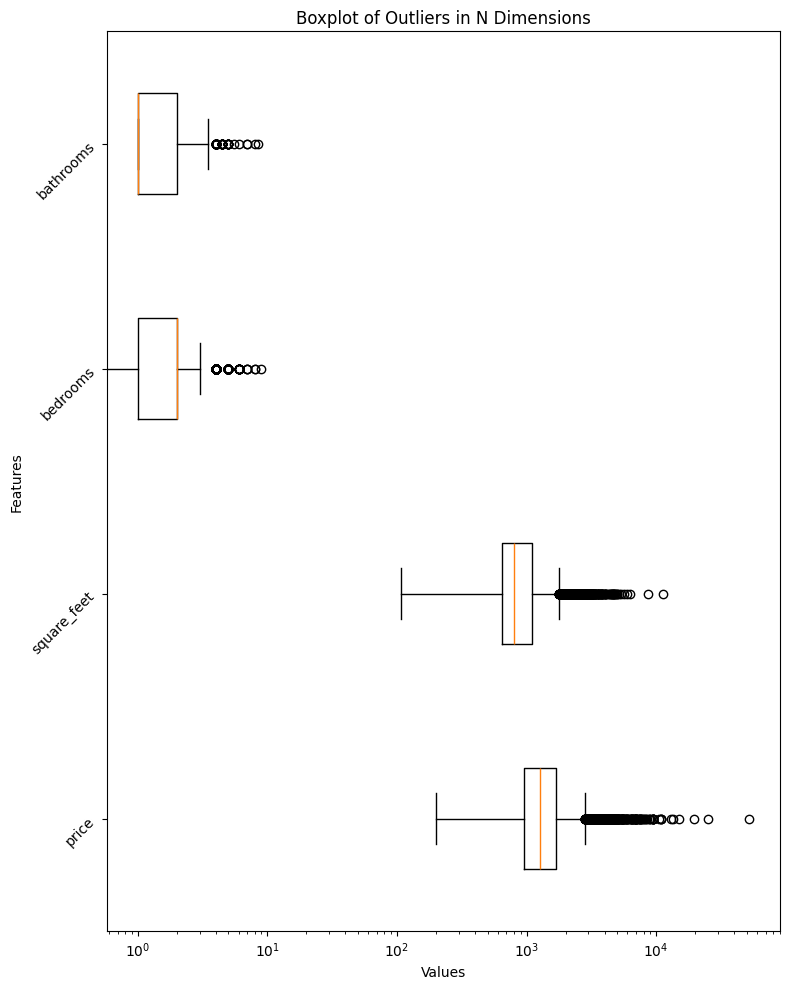

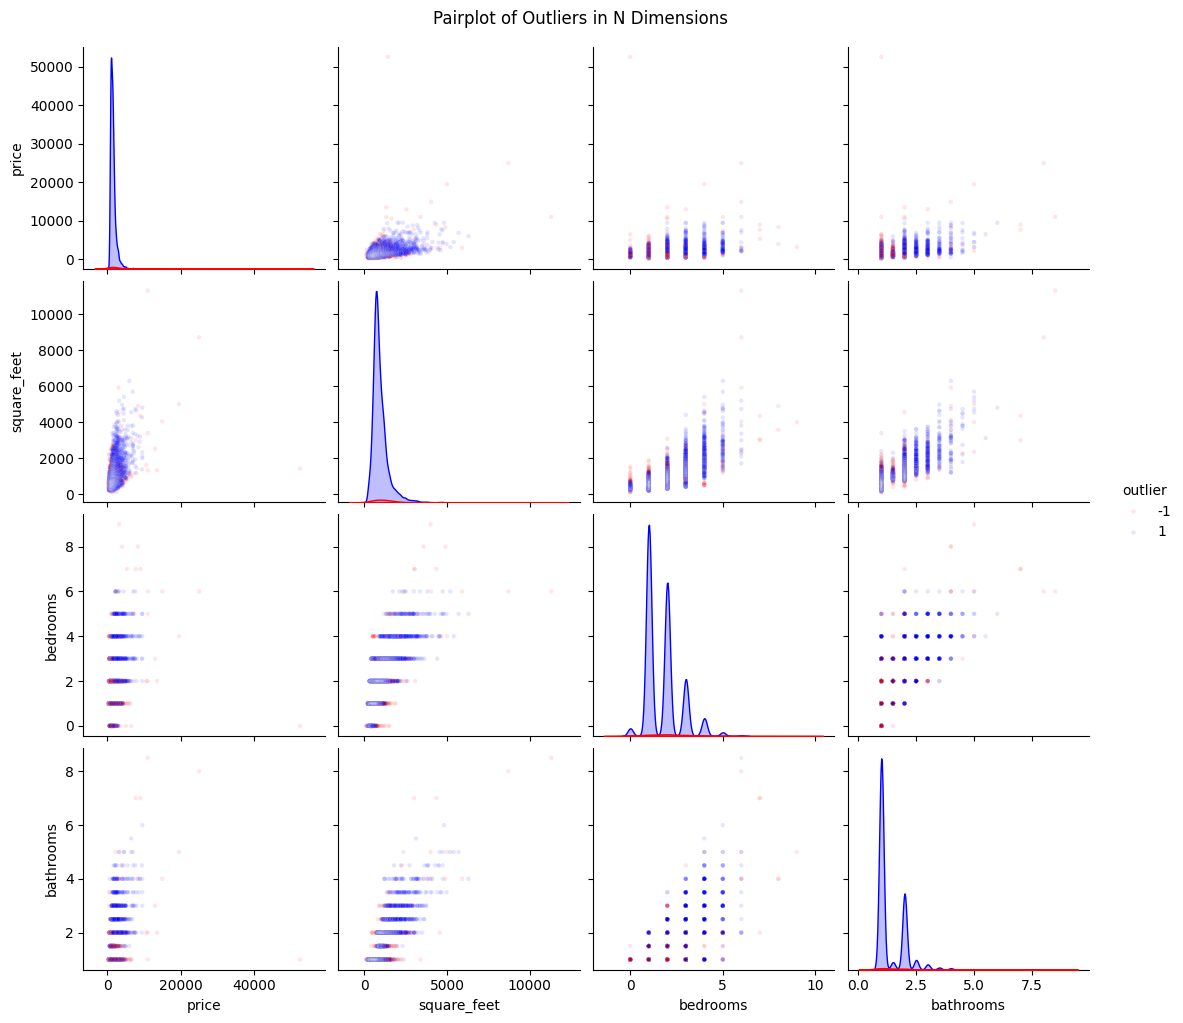

In [430]:
outliers = lof_outlier_detection(rent, columns=search_outliers_cols)

rent_with_outliers = rent.copy()
rent_with_outliers["outlier"] = outliers
show_boxplot(
    rent_with_outliers,
    columns=search_outliers_cols,
    title="Boxplot of Outliers in N Dimensions",
    log_scale=True,
)
plot_pairplot_outliers(
    rent_with_outliers,
    columns=search_outliers_cols,
)

In [431]:
def remove_outliers(df: pd.DataFrame, outlier_mask: pd.Series) -> pd.DataFrame:
    """
    Remove outliers from the dataframe.
    The function takes the following parameters:
    - df: the dataframe to remove outliers from
    - outlier_mask: the mask of outliers to remove:
        - 1: outlier
        - 0: inlier
    """
    df = df.copy()
    df = df.loc[outlier_mask]
    df = df.reset_index(drop=True)
    return df

In [432]:
rent.shape

(9878, 12)

In [433]:
rent = remove_outliers(rent, outlier_mask=outliers.map({-1: False, 1: True}))
rent.shape

(9577, 12)

In [434]:
state_counts = rent["state"].value_counts()
state_columns = state_counts[state_counts > 1].index
rent = rent.loc[rent["state"].isin(state_columns)]
min_state_count = rent["state"].value_counts().min()
print(f"Minimum state count: {min_state_count}")

Minimum state count: 3


In [435]:
state_index = rent["state"]
rent = rent.reset_index(drop=True)

### Convert categorical variables to numerical

In [436]:
def one_hot_encode_column(
    df: pd.DataFrame, column: str, drop_first: bool = False
) -> pd.DataFrame:
    """
    One-hot encode a given column in the dataframe using pd.get_dummies.
    The function returns the dataframe with the one-hot encoded column.
    """
    df = df.copy()
    return pd.get_dummies(df, columns=[column], drop_first=drop_first, dtype=int)

In [437]:
rent["pets_allowed"] = rent["pets_allowed"].fillna("No")

rent = one_hot_encode_column(rent, column="pets_allowed", drop_first=False)

rent.head()

,id,amenities,bathrooms,bedrooms,price,square_feet,state,latitude,longitude,estimated_mean_price_upper,estimated_mean_price_lower,pets_allowed_Cats,"pets_allowed_Cats,Dogs",pets_allowed_Dogs,pets_allowed_No
0,5667891676,"Dishwasher,Elevator,Patio/Deck,Pool,Storage",1.0,0.0,2475.0,130.0,NY,40.7629,-73.9885,1964.655526,1513.710671,0,0,0,1
1,5654898031,"AC,Basketball,Cable or Satellite,Gym,Internet ...",1.0,1.0,1560.0,200.0,NC,35.0960,-77.0272,1226.653273,1160.908371,0,1,0,0
2,5664574876,NaN,1.0,1.0,1000.0,200.0,TX,30.0871,-95.4685,1178.540495,1141.241889,0,0,0,1
3,5668622178,"Cable or Satellite,Clubhouse,Elevator,Internet...",1.0,1.0,544.0,200.0,FL,30.4601,-84.2714,1638.681227,1414.481015,0,0,0,1
4,5668624017,NaN,1.0,1.0,1400.0,219.0,CA,37.7599,-122.4379,2975.736669,2675.360713,0,0,0,1


In [438]:
rent = one_hot_encode_column(rent, column="state", drop_first=False)
rent.head()

,id,amenities,bathrooms,bedrooms,price,square_feet,latitude,longitude,estimated_mean_price_upper,estimated_mean_price_lower,...,state_SC,state_SD,state_TN,state_TX,state_UT,state_VA,state_VT,state_WA,state_WI,state_WV
0,5667891676,"Dishwasher,Elevator,Patio/Deck,Pool,Storage",1.0,0.0,2475.0,130.0,40.7629,-73.9885,1964.655526,1513.710671,...,0,0,0,0,0,0,0,0,0,0
1,5654898031,"AC,Basketball,Cable or Satellite,Gym,Internet ...",1.0,1.0,1560.0,200.0,35.0960,-77.0272,1226.653273,1160.908371,...,0,0,0,0,0,0,0,0,0,0
2,5664574876,NaN,1.0,1.0,1000.0,200.0,30.0871,-95.4685,1178.540495,1141.241889,...,0,0,0,1,0,0,0,0,0,0
3,5668622178,"Cable or Satellite,Clubhouse,Elevator,Internet...",1.0,1.0,544.0,200.0,30.4601,-84.2714,1638.681227,1414.481015,...,0,0,0,0,0,0,0,0,0,0
4,5668624017,NaN,1.0,1.0,1400.0,219.0,37.7599,-122.4379,2975.736669,2675.360713,...,0,0,0,0,0,0,0,0,0,0


In [439]:
rent["amenities"] = rent["amenities"].fillna("Unknown").str.split(",")
rent["amenities"] = rent["amenities"].apply(
    lambda amenity_list: [f"amenity_{i}" for i in amenity_list]
)
rent["count_amenities"] = rent["amenities"].apply(len)
apartment_amenities = rent["amenities"].explode().unique().tolist()
apartment_amenities

['amenity_Dishwasher',
 'amenity_Elevator',
 'amenity_Patio/Deck',
 'amenity_Pool',
 'amenity_Storage',
 'amenity_AC',
 'amenity_Basketball',
 'amenity_Cable or Satellite',
 'amenity_Gym',
 'amenity_Internet Access',
 'amenity_Refrigerator',
 'amenity_Unknown',
 'amenity_Clubhouse',
 'amenity_Parking',
 'amenity_Garbage Disposal',
 'amenity_Fireplace',
 'amenity_Washer Dryer',
 'amenity_Gated',
 'amenity_Hot Tub',
 'amenity_Tennis',
 'amenity_Wood Floors',
 'amenity_View',
 'amenity_Alarm',
 'amenity_Playground',
 'amenity_Doorman',
 'amenity_TV',
 'amenity_Luxury',
 'amenity_Golf']

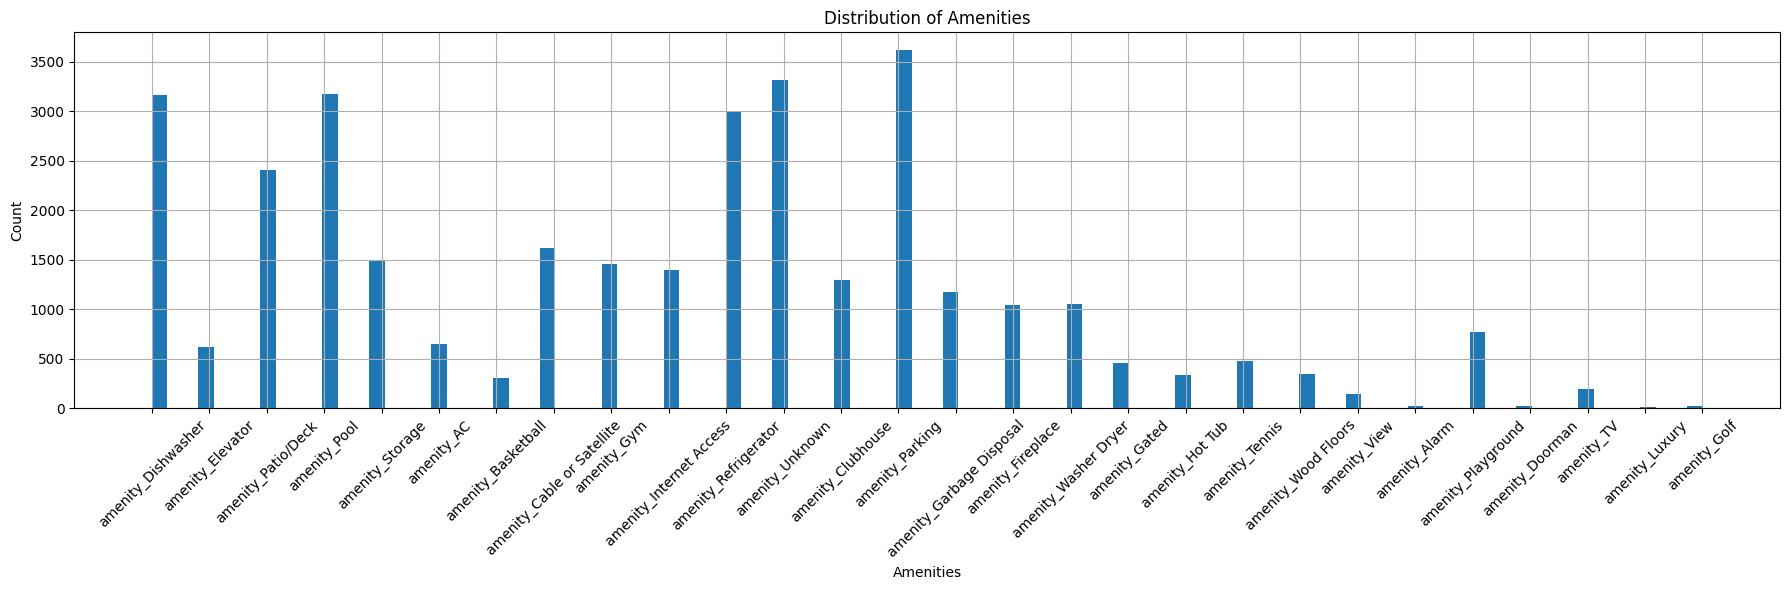

In [440]:
def plot_amenities_distribution(amenties: pd.Series) -> None:
    """
    Plot the distribution of the amenities in the dataframe.
    The function takes the following parameters:
    - df: the dataframe to plot
    - column: the column to plot
    - title: the title of the plot
    """
    plt.figure(figsize=(18, 6))
    data = amenties.explode()
    data.hist(bins=100)
    plt.title("Distribution of Amenities")
    plt.xlabel("Amenities")
    plt.ylabel("Count")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


plot_amenities_distribution(rent["amenities"])

In [441]:
def multi_label_binarize_column(df: pd.DataFrame, column: str) -> pd.DataFrame:
    """
    Multi-label binarize a given column in the dataframe.
    The column is expected to contain lists of values.
    The function returns the dataframe with the multi-label binarized column.
    """
    df = df.copy()

    mlb = MultiLabelBinarizer(sparse_output=False)

    encoded = mlb.fit_transform(df[column])
    encoded_df = pd.DataFrame(encoded, columns=mlb.classes_, index=df.index)
    df = df.join(encoded_df)
    df = df.drop(columns=column)
    return df

In [442]:
rent = multi_label_binarize_column(rent, column="amenities")
rent.head()

,id,bathrooms,bedrooms,price,square_feet,latitude,longitude,estimated_mean_price_upper,estimated_mean_price_lower,pets_allowed_Cats,...,amenity_Playground,amenity_Pool,amenity_Refrigerator,amenity_Storage,amenity_TV,amenity_Tennis,amenity_Unknown,amenity_View,amenity_Washer Dryer,amenity_Wood Floors
0,5667891676,1.0,0.0,2475.0,130.0,40.7629,-73.9885,1964.655526,1513.710671,0,...,0,1,0,1,0,0,0,0,0,0
1,5654898031,1.0,1.0,1560.0,200.0,35.0960,-77.0272,1226.653273,1160.908371,0,...,0,1,1,0,0,0,0,0,0,0
2,5664574876,1.0,1.0,1000.0,200.0,30.0871,-95.4685,1178.540495,1141.241889,0,...,0,0,0,0,0,0,1,0,0,0
3,5668622178,1.0,1.0,544.0,200.0,30.4601,-84.2714,1638.681227,1414.481015,0,...,0,1,1,0,0,0,0,0,0,0
4,5668624017,1.0,1.0,1400.0,219.0,37.7599,-122.4379,2975.736669,2675.360713,0,...,0,0,0,0,0,0,1,0,0,0


## Feature Engineering

### Add POI count

Loads the POI count from the POI count file and adds it to the data.

The POI count file is a parquet file from the data fetched from the Overpass API. The POI count is the number of points of interest within a 1 Kilometer radius from the apartment.

This dataset is structured as follows:
- `id`: The id of the apartment, the same as the id in the apartment dataset.
- `tag`: The tag of the POI, such as `restaurant`, `school`, etc.
- `count`: The number of POIs of that tag within a 1 Kilometer radius from the apartment.
- `type`: The type of the POI based on the Overpass API. This is a more general type than the tag, such as `amenity`, `tourism`, etc.

In [443]:
poi_count = pd.read_parquet(poi_count_path)
poi_count

,id,tag,count,type
0,5668626895,pub,4,amenity
1,5668626895,restaurant,28,amenity
2,5668626895,fast_food,9,amenity
3,5668626895,museum,1,tourism
4,5668626895,bar,13,amenity
...,...,...,...,...
56945,5668662559,music_school,1,amenity
56946,5668662559,cinema,3,amenity
56947,5668662559,dancing_school,1,amenity
56948,5668662559,prep_school,2,amenity


In [444]:
poi_count.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 56950 entries, 0 to 56949
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      56950 non-null  object
 1   tag     56950 non-null  object
 2   count   56950 non-null  int64 
 3   type    56950 non-null  object
dtypes: int64(1), object(3)
memory usage: 1.7+ MB


In [445]:
poi_count.describe()

,count
count,56950.000000
mean,5.074732
std,12.257293
min,1.000000
25%,1.000000
50%,2.000000
75%,5.000000
max,585.000000


In [446]:
poi_count[["tag"]].describe()

,tag
count,56950
unique,55
top,school
freq,7870


#### Group tags by category
The tags are grouped by category to reduce the number of features. The categories are:
- `food`: Restaurants, bars, cafes, etc.
- `education`: Schools, universities, etc.
- `health`: Hospitals, clinics, etc.
- `transport`: Train stations, bus stops, etc.
- `leisure`: Parks, gyms, etc.
- `attraction`: Tourist attractions, museums, etc.
- `safety`: Police stations, fire stations, etc.
- `natural`: Natural features, such as beaches, mountains, etc.

In [447]:
def filter_tags(filter_value: str | list[str], tags: set[str]) -> set[str]:
    """
    Filter a set of tags by a value.
    """
    if isinstance(filter_value, str):
        filter_value = [filter_value]
    return {t for t in tags if any(fv in t for fv in filter_value)}


def categorize_tags(
    df: pd.DataFrame, category_map: dict[str, Sequence[str]]
) -> pd.DataFrame:
    """
    Categorize a set of tags by a value.
    category_map is a dictionary with the following structure:
    {
        "category": {"filter_value_1", "filter_value_2", ...},
        ...
    }
    """
    df = df.copy()
    df["category"] = pd.NA
    for category, filter_value in category_map.items():
        tags = filter_tags(filter_value, df["tag"].unique())
        df.loc[df["tag"].isin(tags), "category"] = category
    return df

In [448]:
categorized_poi_count = categorize_tags(
    poi_count,
    category_map={
        "food": ["food", "restaurant", "cafe", "bar", "pub"],
        "shopping": ["shopping", "store"],
        "transportation": ["transportation", "bus", "subway", "station"],
        "health": ["hospital", "clinic", "doctor", "health", "pharmacy"],
        "education": ["school", "college", "university"],
        "leisure": ["leisure", "park", "gym", "cinema", "theater"],
        "attraction": ["attraction", "museum", "gallery", "park"],
        "hotel": ["hotel", "motel", "hostel"],
        "safety": ["police", "fire_station", "emergency", "safety", "security"],
        "natural": ["beach"],
    },
)
categorized_poi_count

,id,tag,count,type,category
0,5668626895,pub,4,amenity,food
1,5668626895,restaurant,28,amenity,food
2,5668626895,fast_food,9,amenity,food
3,5668626895,museum,1,tourism,attraction
4,5668626895,bar,13,amenity,food
...,...,...,...,...,...
56945,5668662559,music_school,1,amenity,education
56946,5668662559,cinema,3,amenity,leisure
56947,5668662559,dancing_school,1,amenity,education
56948,5668662559,prep_school,2,amenity,education


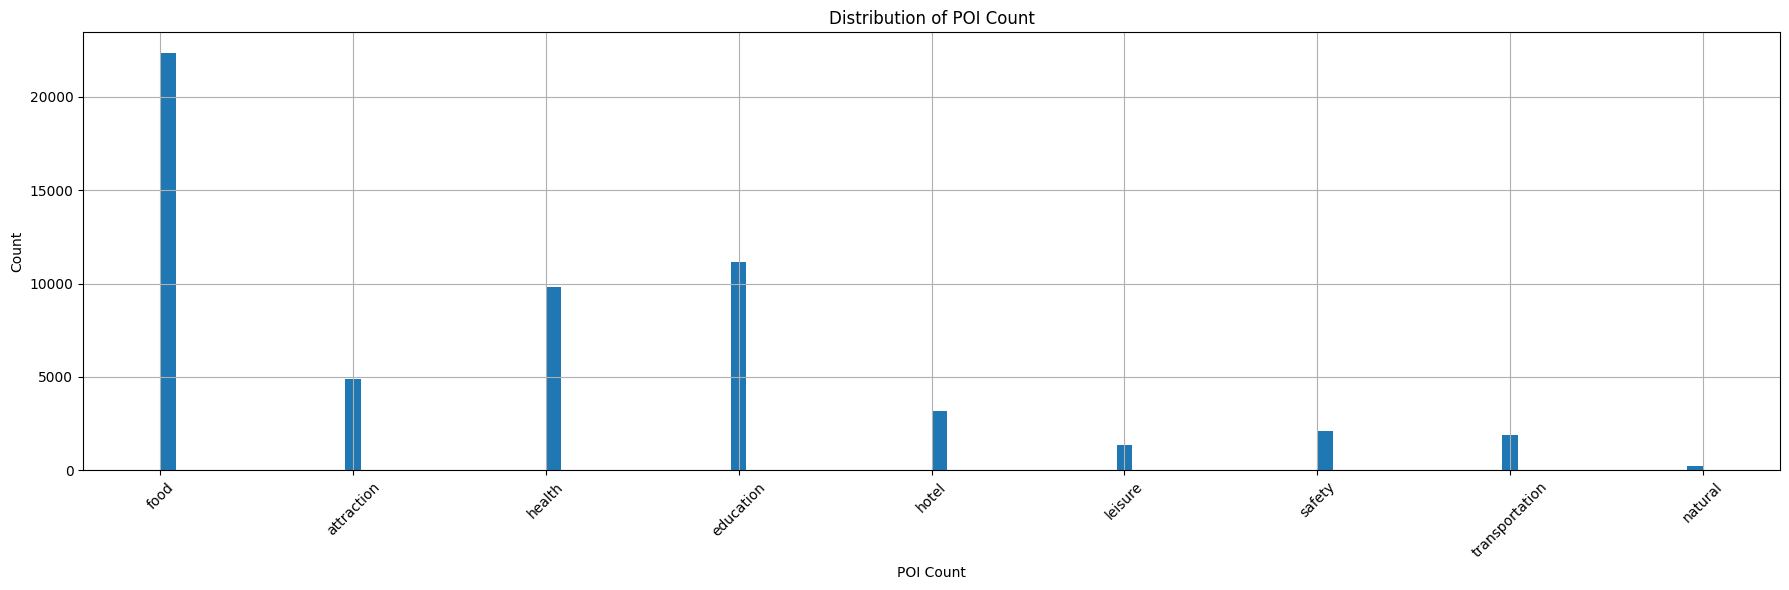

In [449]:
def plot_poi_distribution(poi_count: pd.DataFrame, column: str = "tag") -> None:
    """
    Plot the distribution of the POI count in the dataframe.
    The function takes the following parameters:
    - df: the dataframe to plot
    - column: the column to plot
    - title: the title of the plot
    """
    plt.figure(figsize=(18, 6))
    data = poi_count[column]
    data.hist(bins=100)
    plt.title("Distribution of POI Count")
    plt.xlabel("POI Count")
    plt.ylabel("Count")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


plot_poi_distribution(categorized_poi_count, column="category")

#### Preprocess the POI count

The POI count is preprocessed by:
- Creating a pivot table with the id as the index and the tag as the columns.
- The pivot table aggregates the count of each tag for each id.
- Filling missing values with 0.
- Renaming the columns with the `_count` suffix.

In [450]:
poi_pivot_table = categorized_poi_count.pivot_table(
    index="id",
    columns="category",
    values="count",
    aggfunc="sum",  # or "first" depending on your data
    fill_value=0,
)

# Optionally: Rename columns to include "_count" suffix
poi_cols = [f"{col}_count" for col in poi_pivot_table.columns]
poi_pivot_table.columns = poi_cols

# Reset index if you want `id` as a column
poi_pivot_table

,attraction_count,education_count,food_count,health_count,hotel_count,leisure_count,natural_count,safety_count,transportation_count
id,,,,,,,,,
5508654087,0,1,4,0,0,0,0,0,0
5508654149,0,1,2,1,0,0,0,0,0
5508654460,0,1,15,0,1,0,0,0,0
5508654607,23,7,185,4,20,1,0,2,7
5508654638,0,1,4,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...
5668643363,0,2,38,4,0,0,0,0,0
5668643383,1,3,17,1,1,0,0,1,0
5668643398,0,1,9,3,0,0,0,0,0


#### Drop empty categories

The categories that have few or no POIs are dropped. 

This is done to reduce the number of features and to avoid overfitting and reduce the noise in the data.

We analyze the POI count and calculate the emptiness of each category. The emptiness is calculated as the sum of observations with 0 POIs in that category divided by the total number of observations.

Finally we drop the categories with an emptiness greater than 0.5. This means that more than 50% of the observations have 0 POIs in that category.

In [451]:
def calculate_emptiness_rate(df: pd.DataFrame) -> pd.Series:
    """
    Calculate the emptiness rate of a given column in the dataframe.
    The function returns a series with the emptiness rate for each row.
    """
    df = df.copy()
    df.fillna(0, inplace=True)
    emptiness = {col: ((df[col] == 0).sum() / len(df)) for col in df.columns}

    return (
        pd.DataFrame(emptiness, index=[0])
        .T.rename(columns={0: "emptiness_rate"})
        .sort_values(ascending=True, by="emptiness_rate")
    )

In [452]:
emptiness_df = calculate_emptiness_rate(poi_pivot_table)
emptiness_df

,emptiness_rate
education_count,0.102462
food_count,0.112620
health_count,0.365022
attraction_count,0.613338
hotel_count,0.653417
safety_count,0.769791
transportation_count,0.838909
leisure_count,0.849398
natural_count,0.971624


In [453]:
def filter_tags_by_emptiness_rate(
    tags: set[str], emptiness_df: pd.DataFrame, threshold: float = 0.5
) -> set[str]:
    """
    Filter tags by emptiness rate.
    The function takes the following parameters:
    - tags: the set of tags to filter
    - emptiness_df: the dataframe with the emptiness rate of each tag
    - threshold: the threshold for the emptiness rate
    """
    return {tag for tag in tags if emptiness_df.loc[tag, "emptiness_rate"] < threshold}

In [454]:
rename_emptiness_df = emptiness_df.copy()
rename_emptiness_df.index = emptiness_df.index.str.removesuffix("_count")
rename_emptiness_df

,emptiness_rate
education,0.102462
food,0.112620
health,0.365022
attraction,0.613338
hotel,0.653417
safety,0.769791
transportation,0.838909
leisure,0.849398
natural,0.971624


#### Merge POI count with the data

The POI count is merged with the data using the `id` column. The `id` column is the same in both datasets. The merge is done using a left join, so that all observations in the data are kept, even if they don't have a POI count.

In [455]:
rent_with_poi = pd.merge(
    rent,
    poi_pivot_table,
    left_on=["id"],
    right_index=True,
    how="left",
).drop(columns=["id"])  # R1: Irrelevant

# Fill missing values in the new columns with 0
new_poi_amenities = rent_with_poi.columns.difference(rent.columns).tolist()
rent_with_poi[new_poi_amenities] = rent_with_poi[new_poi_amenities].fillna(0)
rent_with_poi

,bathrooms,bedrooms,price,square_feet,latitude,longitude,estimated_mean_price_upper,estimated_mean_price_lower,pets_allowed_Cats,"pets_allowed_Cats,Dogs",...,amenity_Wood Floors,attraction_count,education_count,food_count,health_count,hotel_count,leisure_count,natural_count,safety_count,transportation_count
0,1.0,0.0,2475.0,130.0,40.7629,-73.9885,1964.655526,1513.710671,0,0,...,0,24.0,25.0,608.0,29.0,108.0,5.0,0.0,3.0,123.0
1,1.0,1.0,1560.0,200.0,35.0960,-77.0272,1226.653273,1160.908371,0,1,...,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,1.0,1.0,1000.0,200.0,30.0871,-95.4685,1178.540495,1141.241889,0,0,...,0,0.0,1.0,5.0,0.0,0.0,0.0,0.0,0.0,0.0
3,1.0,1.0,544.0,200.0,30.4601,-84.2714,1638.681227,1414.481015,0,0,...,0,1.0,4.0,38.0,1.0,0.0,0.0,0.0,1.0,0.0
4,1.0,1.0,1400.0,219.0,37.7599,-122.4379,2975.736669,2675.360713,0,0,...,0,5.0,13.0,71.0,8.0,2.0,1.0,0.0,0.0,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9571,5.0,6.0,3200.0,5199.0,33.4072,-84.4523,1304.778644,1224.845012,0,0,...,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9572,5.0,4.0,4500.0,5407.0,44.8653,-93.4749,1443.456222,1288.670475,0,0,...,0,0.0,1.0,4.0,2.0,0.0,0.0,0.0,0.0,0.0
9573,5.0,5.0,6900.0,5700.0,28.1253,-82.4468,1638.681227,1414.481015,0,1,...,0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9574,4.0,5.0,6000.0,6300.0,44.9000,-93.3233,1443.456222,1288.670475,0,0,...,0,0.0,2.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0


In [456]:
rent_with_poi.isna().sum()

bathrooms               0
bedrooms                0
price                   0
square_feet             0
latitude                0
                       ..
hotel_count             0
leisure_count           0
natural_count           0
safety_count            0
transportation_count    0
Length: 99, dtype: int64

### Clustering regions

The regions are clustered using the KMeans algorithm. The KMeans algorithm is a popular method for clustering data points into groups based on their features. It works by iteratively assigning data points to the nearest cluster center and updating the cluster centers based on the assigned points.


In [457]:
def determine_optimal_clusters(
    data: np.ndarray, max_clusters: int = MAX_CLUSTERS
) -> tuple[list[int], list[float], list[float]]:
    """Usa o método do cotovelo e silhouette score para encontrar o número ideal de clusters."""
    wcss = []  # Within-cluster sum of squares
    silhouette_scores = []
    clusters_range = list(range(2, max_clusters + 1))

    for k in clusters_range:
        kmeans = KMeans(n_clusters=k, random_state=RANDOM_SEED, n_init=10)
        labels = kmeans.fit_predict(data)
        wcss.append(kmeans.inertia_)
        silhouette_scores.append(silhouette_score(data, labels))

    return clusters_range, wcss, silhouette_scores


def plot_cluster_metrics(
    clusters_range: list[int], wcss: list[float], silhouette_scores: list[float]
) -> None:
    """Plota os gráficos do método do cotovelo e silhouette score."""
    _, ax = plt.subplots(1, 2, figsize=(12, 5))

    ax[0].plot(clusters_range, wcss, marker="o", linestyle="-")
    ax[0].set_title("Método do Cotovelo")
    ax[0].set_xlabel("Número de Clusters")
    ax[0].set_ylabel("WCSS")

    ax[1].plot(clusters_range, silhouette_scores, marker="o", linestyle="-")
    ax[1].set_title("Silhouette Score")
    ax[1].set_xlabel("Número de Clusters")
    ax[1].set_ylabel("Score")

    plt.show()

#### Using the Elbow method to find the optimal number of clusters

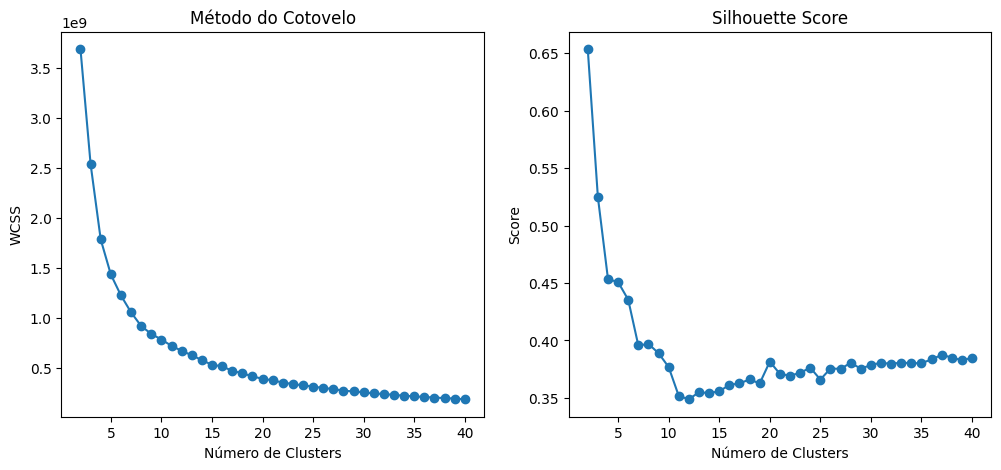

In [458]:
cluster_cols = [
    "estimated_mean_price_upper",
    "estimated_mean_price_lower",
    "square_feet",
    "latitude",
    "longitude",
]
clusters_range, wcss, silhouette_scores = determine_optimal_clusters(
    rent_with_poi[cluster_cols].values
)
plot_cluster_metrics(clusters_range, wcss, silhouette_scores)

In [459]:
N_CLUSTERS = 20

In [460]:
def apply_kmeans_clustering(
    X: pd.DataFrame, n_clusters: int, cluster_cols: list[str]
) -> tuple[pd.DataFrame, KMeans]:
    """Applies KMeans clustering to the data."""
    X = X.copy()
    X_filtered = X[cluster_cols].values

    kmeans = KMeans(n_clusters=n_clusters, random_state=RANDOM_SEED, n_init=10)

    X["cluster"] = kmeans.fit_predict(X_filtered)
    X["dist_to_cluster_center"] = [
        np.linalg.norm(x - kmeans.cluster_centers_[cluster])
        for x, cluster in zip(X_filtered, kmeans.labels_)
    ]

    return X, kmeans


def plot_clusters_on_map(
    df: pd.DataFrame,
    cluster_col: str = "cluster",
    lat_col: str = "latitude",
    lon_col: str = "longitude",
) -> None:
    """
    Plots clusters on a map using latitude and longitude.
    """
    plt.figure(figsize=(10, 8))
    scatter = plt.scatter(
        df[lon_col],
        df[lat_col],
        c=df[cluster_col],
        cmap="tab20",
        s=10,
        alpha=0.6,
    )
    plt.xlabel("Longitude")
    plt.ylabel("Latitude")
    plt.title("Apartment Clusters by Region")
    plt.colorbar(scatter, label="Cluster")
    plt.tight_layout()
    plt.show()

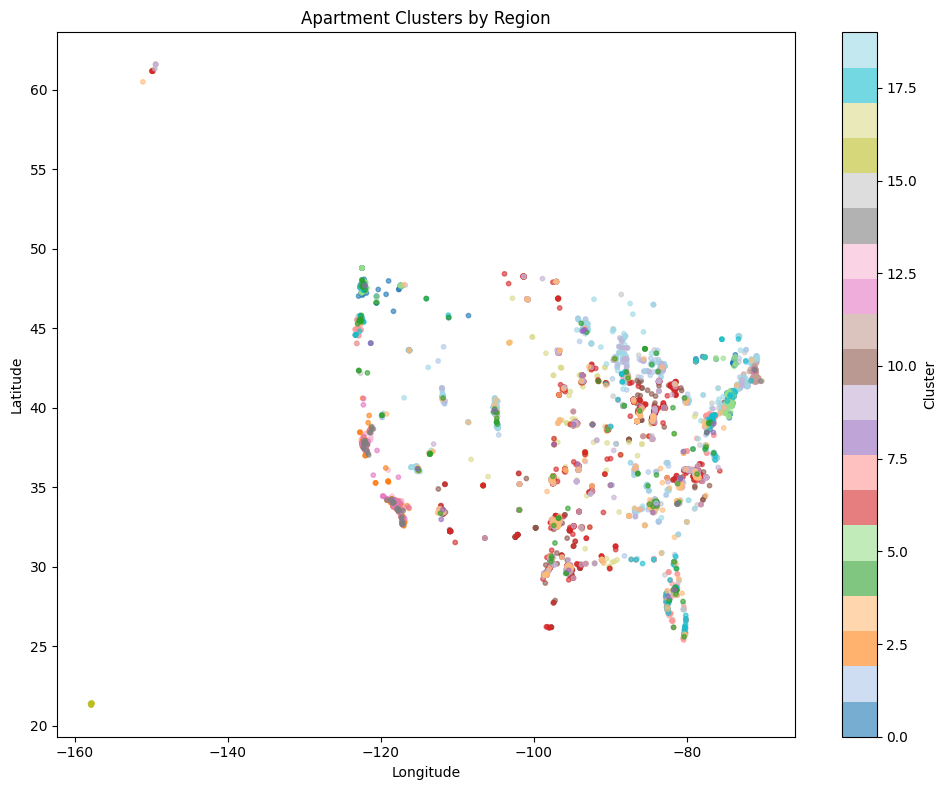

In [461]:
rent_with_poi, kmeans = apply_kmeans_clustering(
    rent_with_poi, n_clusters=N_CLUSTERS, cluster_cols=cluster_cols
)
plot_clusters_on_map(rent_with_poi)

In [462]:
rent_with_poi = one_hot_encode_column(rent_with_poi, column="cluster", drop_first=False)
rent_with_poi.head()

,bathrooms,bedrooms,price,square_feet,latitude,longitude,estimated_mean_price_upper,estimated_mean_price_lower,pets_allowed_Cats,"pets_allowed_Cats,Dogs",...,cluster_10,cluster_11,cluster_12,cluster_13,cluster_14,cluster_15,cluster_16,cluster_17,cluster_18,cluster_19
0,1.0,0.0,2475.0,130.0,40.7629,-73.9885,1964.655526,1513.710671,0,0,...,0,0,0,0,0,1,0,0,0,0
1,1.0,1.0,1560.0,200.0,35.0960,-77.0272,1226.653273,1160.908371,0,1,...,1,0,0,0,0,0,0,0,0,0
2,1.0,1.0,1000.0,200.0,30.0871,-95.4685,1178.540495,1141.241889,0,0,...,1,0,0,0,0,0,0,0,0,0
3,1.0,1.0,544.0,200.0,30.4601,-84.2714,1638.681227,1414.481015,0,0,...,0,0,0,0,0,1,0,0,0,0
4,1.0,1.0,1400.0,219.0,37.7599,-122.4379,2975.736669,2675.360713,0,0,...,0,0,0,1,0,0,0,0,0,0


### Analyze the correlation

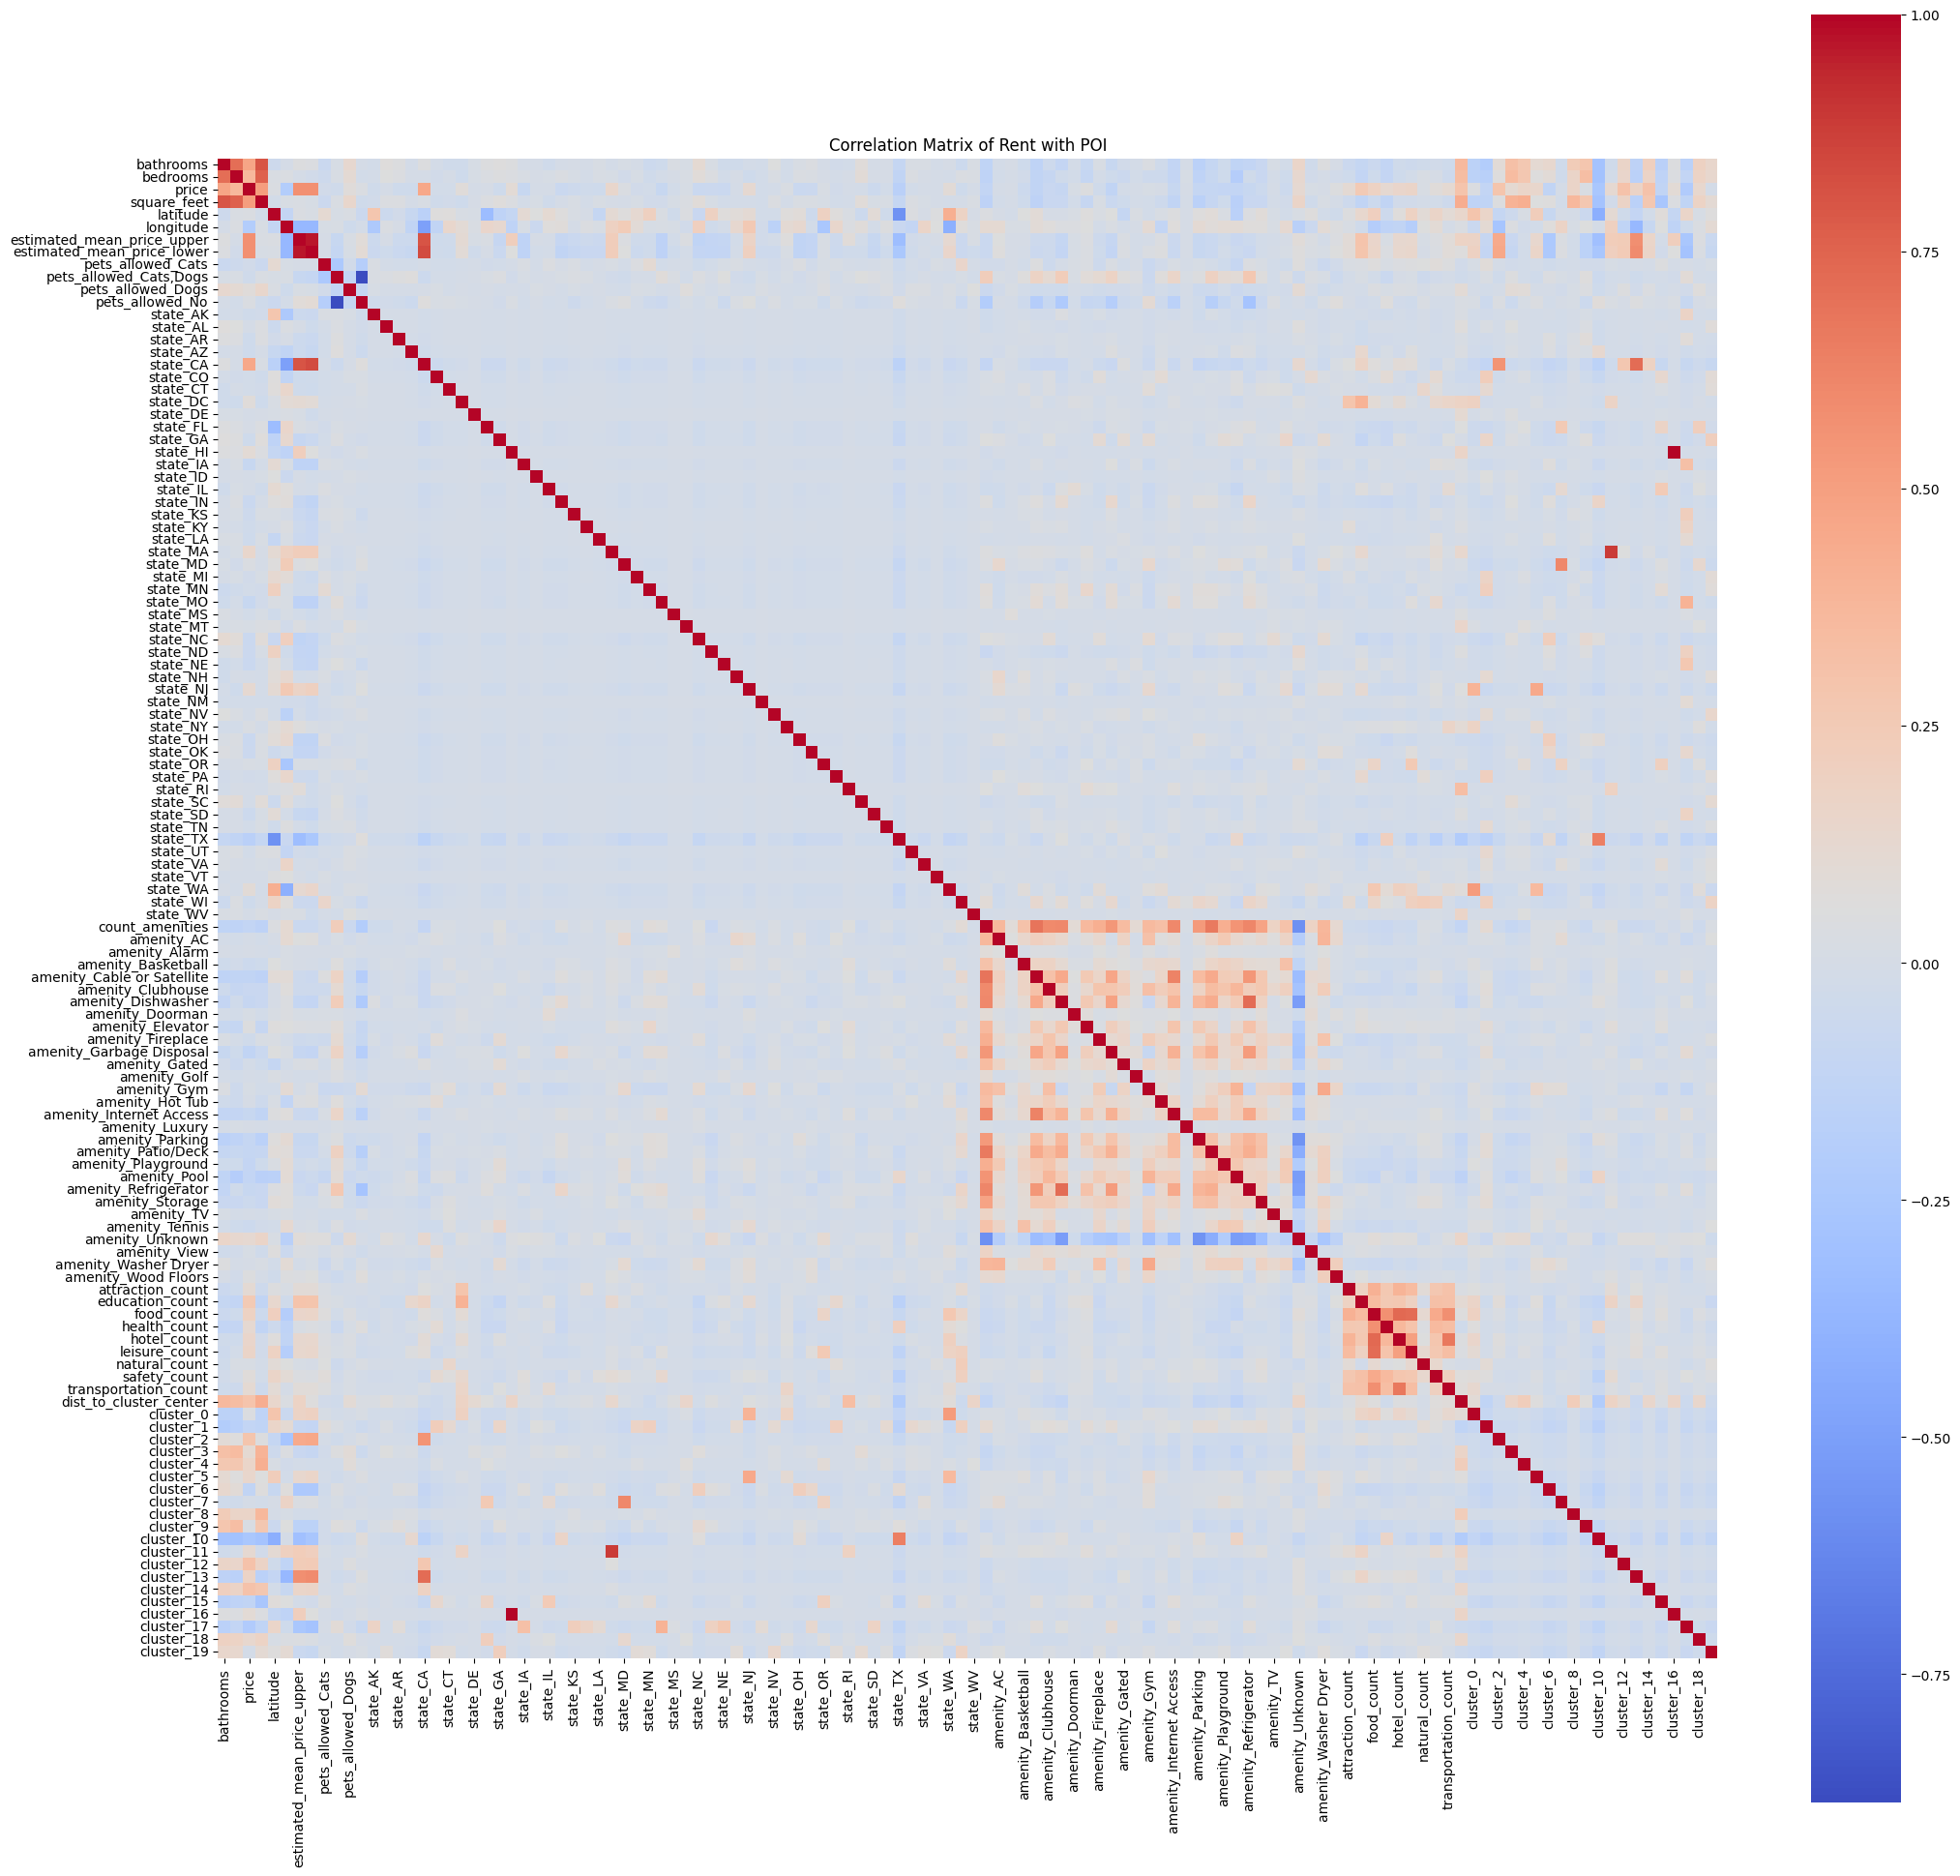

In [463]:
def plot_correlation_matrix(
    df: pd.DataFrame,
    title: str = "Correlation Matrix",
    figsize: tuple[int, int] = (12, 10),
    annotate_value: bool = False,
) -> None:
    """
    Plot the correlation matrix of the dataframe.
    The function takes the following parameters:
    - df: the dataframe to plot
    - title: the title of the plot
    - figsize: the size of the figure
    """
    plt.figure(figsize=figsize)
    sns.heatmap(
        df.corr(),
        cmap="coolwarm",
        annot=annotate_value,  # Show correlation values in the squares
        fmt=".2f",
        square=True,
        cbar_kws={"shrink": 0.8},
    )
    plt.title(title)
    plt.show()


# Compute the correlation matrix
plot_correlation_matrix(
    rent_with_poi,
    title="Correlation Matrix of Rent with POI",
    figsize=(25, 30),
)

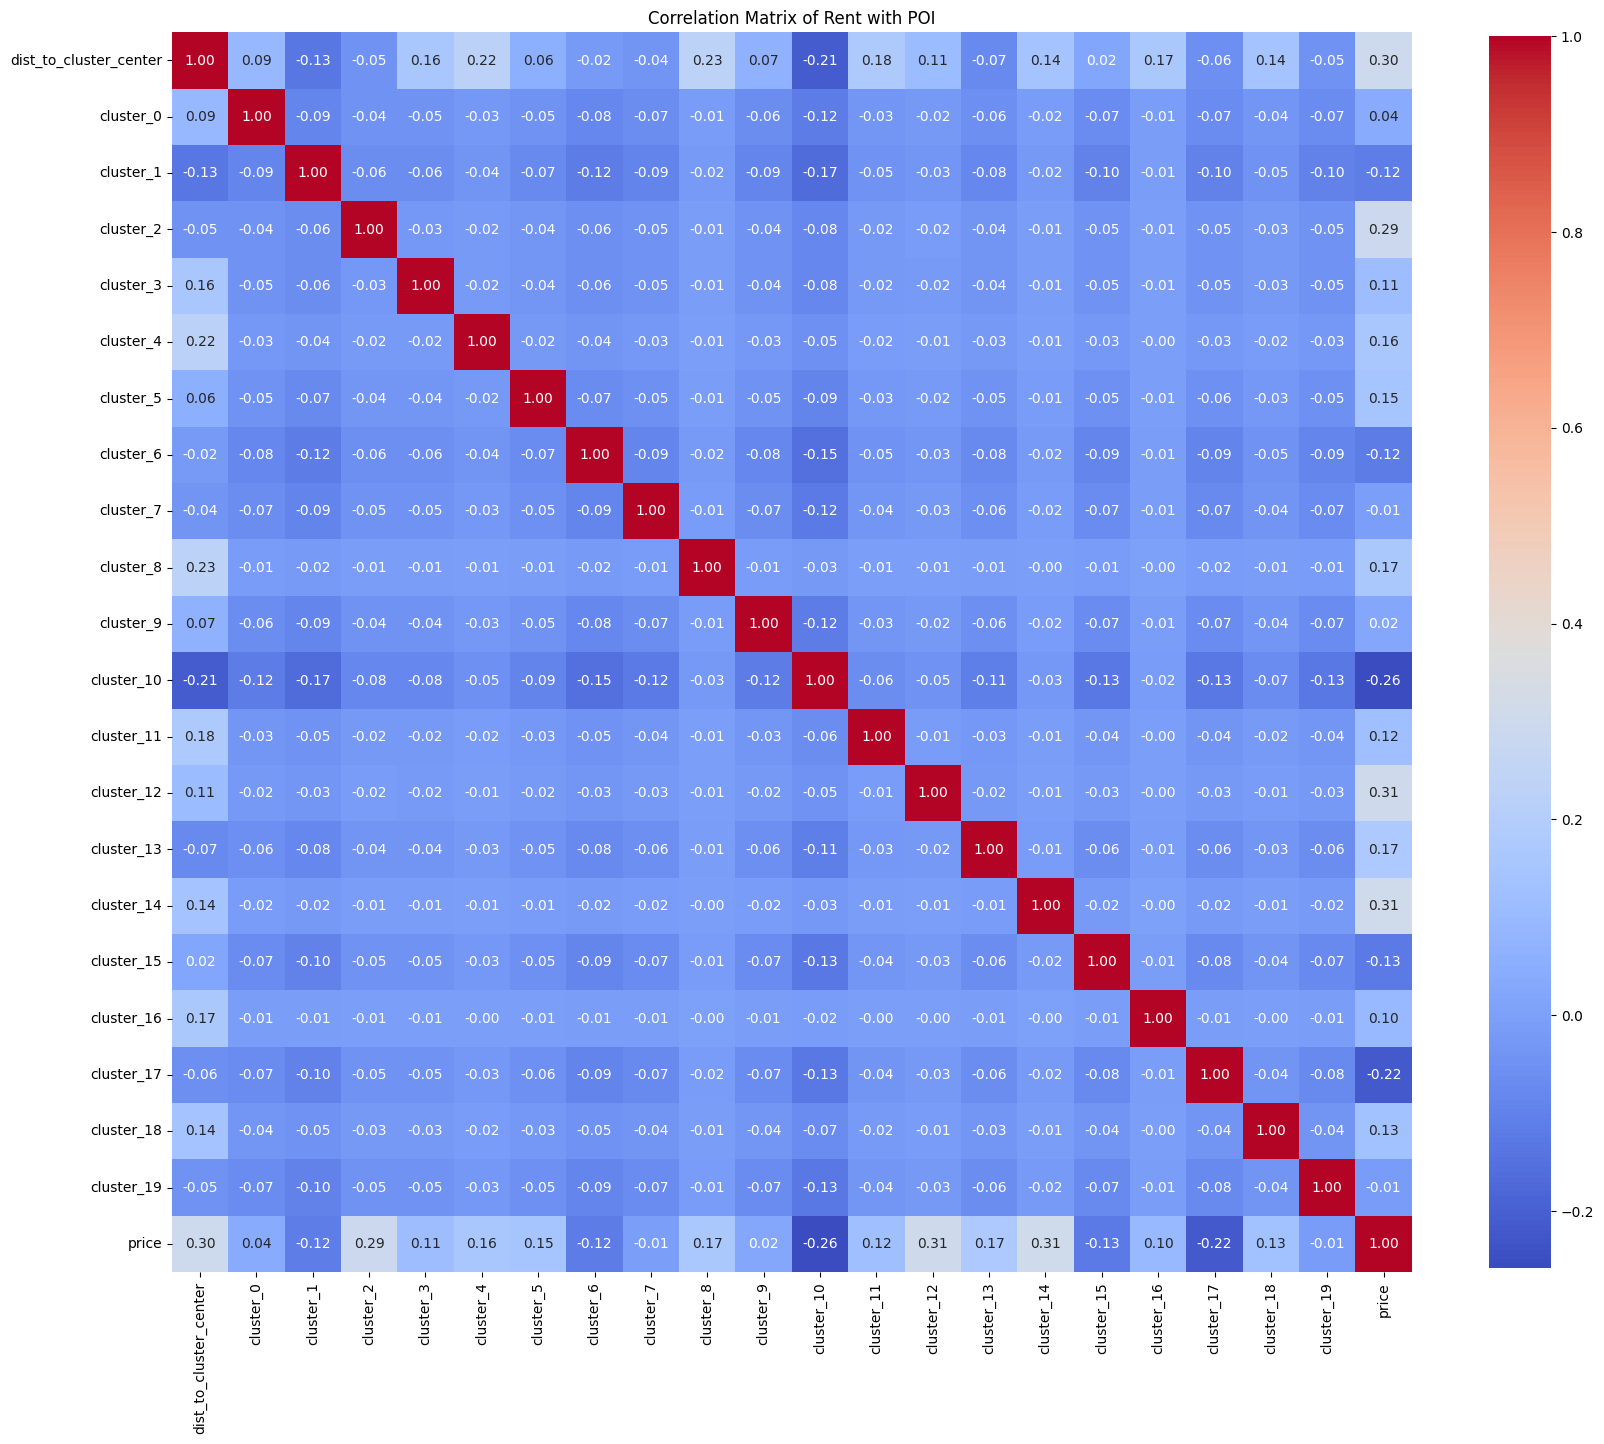

In [464]:
cluster_cols = [col for col in rent_with_poi.columns if "cluster" in col]
plot_correlation_matrix(
    rent_with_poi[cluster_cols + [TARGET]],
    title="Correlation Matrix of Rent with POI",
    figsize=(20, 20),
    annotate_value=True,
)

#### Filter the features based on correlation

The features are filtered based on their correlation with the target variable, `price`. Only features with an absolute correlation greater than `0.1` are retained. This helps reduce the number of features, minimize noise, and prevent overfitting.

**Notes:**
- Categorical features are excluded from the correlation analysis, as correlation is only defined for numerical variables.
- The `price` column itself is excluded from the features, since it is the target variable.
- The `latitude` and `longitude` columns are also ignored, as they are primarily used for visualization and clustering, not for prediction.


In [465]:
def filter_by_correlation(
    df: pd.DataFrame,
    target: str = TARGET,
    threshold: float = 0.3,
    ignore: str | list[str] | None = None,
) -> pd.DataFrame:
    """
    Filter the dataframe by correlation.
    The function takes the following parameters:
    - df: the dataframe to filter
    - threshold: the threshold to filter by
    """
    if isinstance(ignore, str):
        ignore = [ignore]
    if ignore is None:
        ignore = []

    filtered_columns = df.columns.difference(ignore)

    corr_matrix = df[filtered_columns].corr()
    target_corr = corr_matrix[target]

    target_corr = target_corr[target_corr.abs() > threshold]

    print(f"Number of features with correlation > {threshold}: {len(target_corr)}")

    print(f"Correlation features: {target_corr.index.tolist()}")

    plot_size = len(target_corr.index)
    plot_correlation_matrix(
        df[target_corr.index],
        title=f"Correlation Matrix of Rent with POI (threshold: {threshold})",
        figsize=(plot_size, plot_size),
        annotate_value=True,
    )

    remain_cols = filtered_columns.difference(target_corr.index)

    return df.drop(columns=remain_cols)

Number of features with correlation > 0.1: 21
Correlation features: ['amenity_Cable or Satellite', 'amenity_Garbage Disposal', 'amenity_Patio/Deck', 'amenity_Playground', 'amenity_Pool', 'amenity_Unknown', 'attraction_count', 'bathrooms', 'bedrooms', 'count_amenities', 'dist_to_cluster_center', 'education_count', 'estimated_mean_price_lower', 'estimated_mean_price_upper', 'food_count', 'health_count', 'hotel_count', 'leisure_count', 'price', 'square_feet', 'transportation_count']


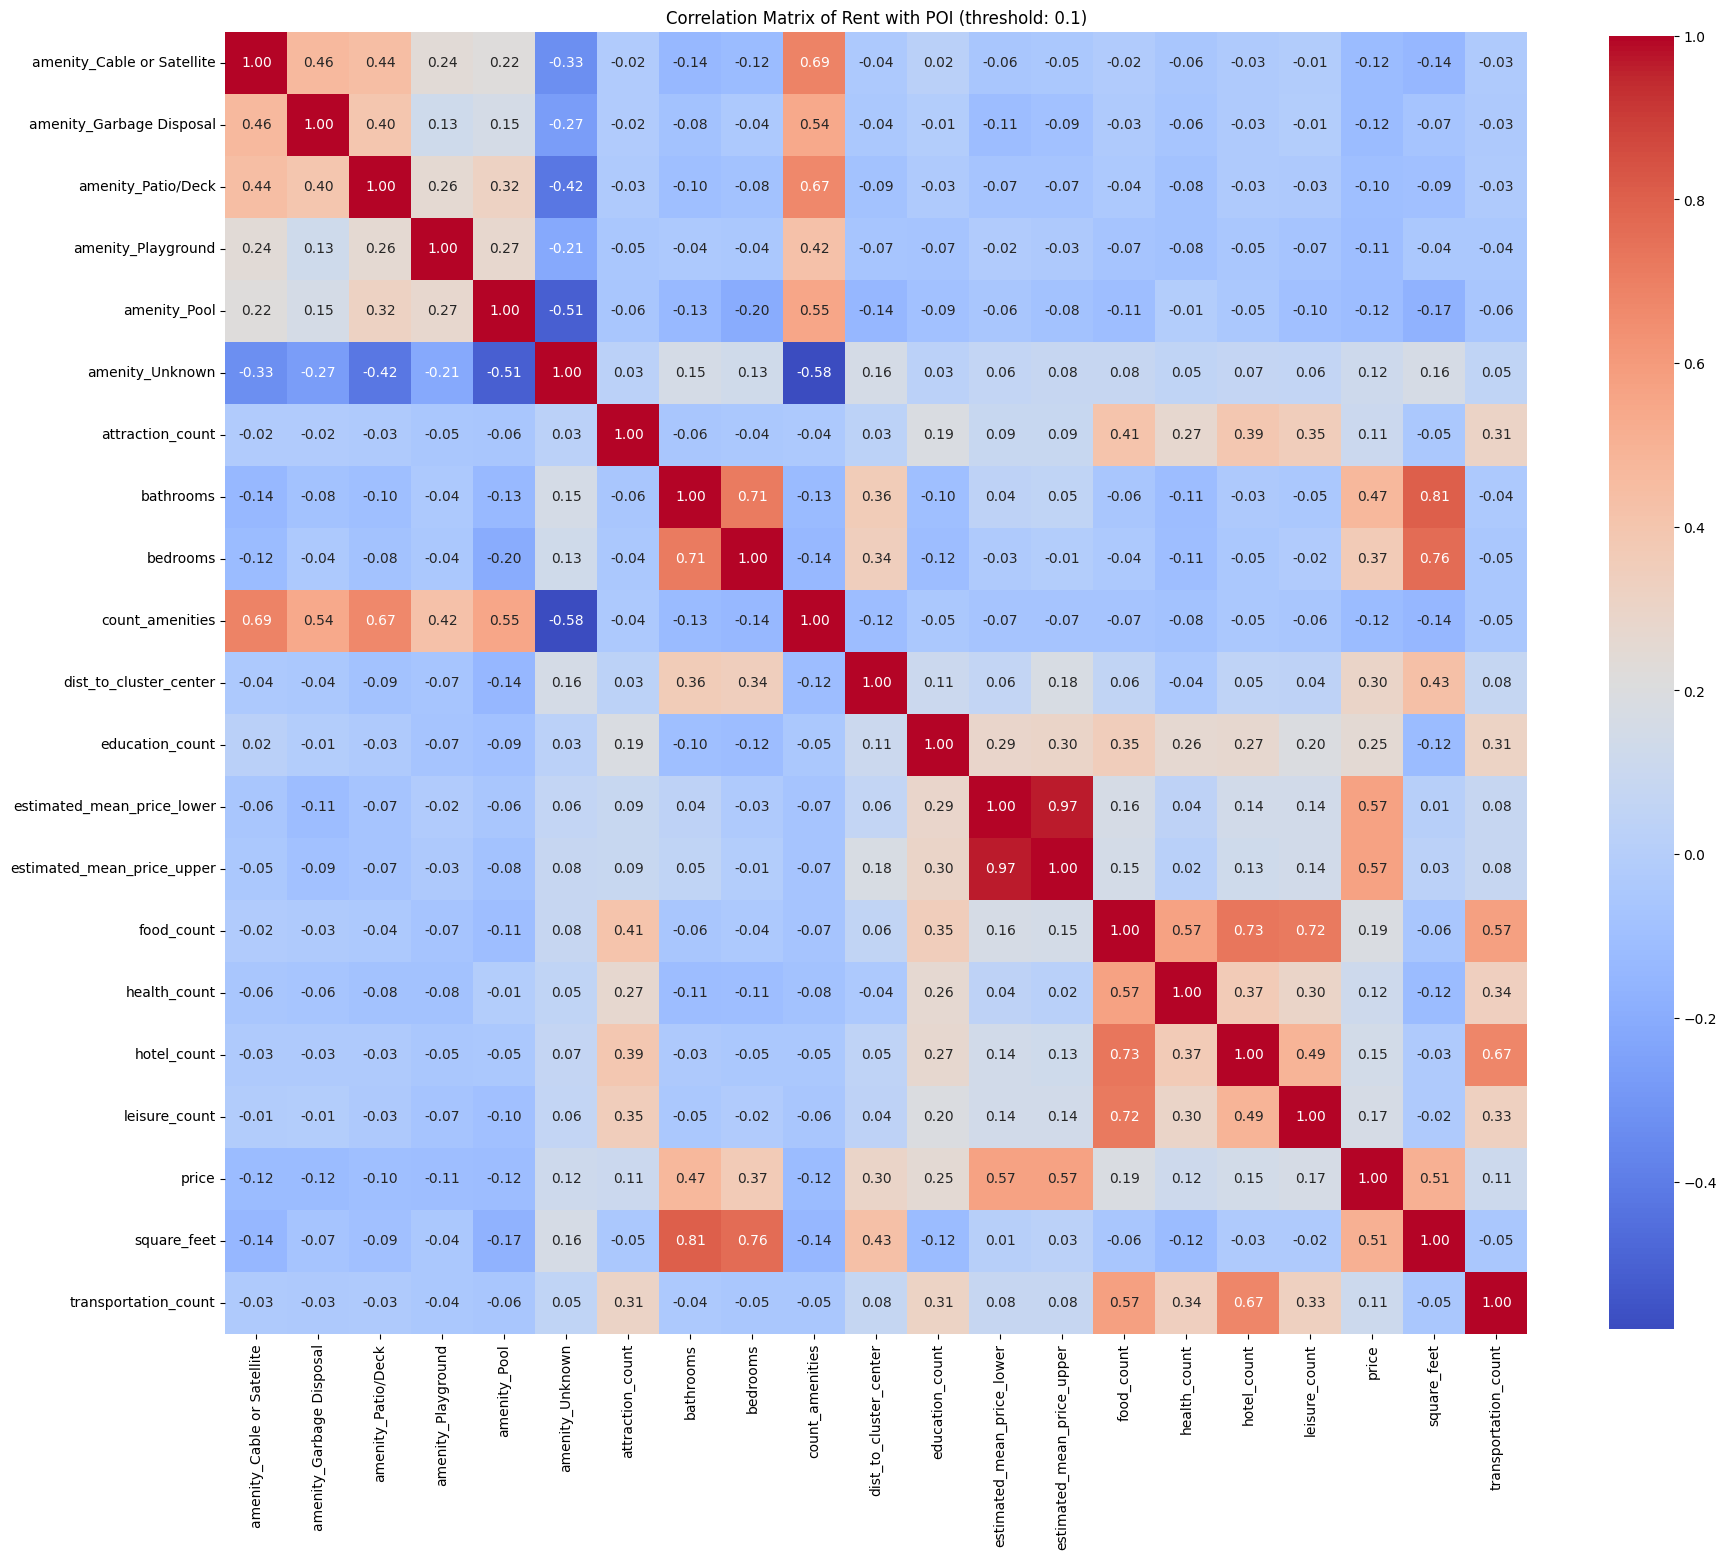

,bathrooms,bedrooms,price,square_feet,latitude,longitude,estimated_mean_price_upper,estimated_mean_price_lower,pets_allowed_Cats,"pets_allowed_Cats,Dogs",...,cluster_10,cluster_11,cluster_12,cluster_13,cluster_14,cluster_15,cluster_16,cluster_17,cluster_18,cluster_19
0,1.0,0.0,2475.0,130.0,40.7629,-73.9885,1964.655526,1513.710671,0,0,...,0,0,0,0,0,1,0,0,0,0
1,1.0,1.0,1560.0,200.0,35.0960,-77.0272,1226.653273,1160.908371,0,1,...,1,0,0,0,0,0,0,0,0,0
2,1.0,1.0,1000.0,200.0,30.0871,-95.4685,1178.540495,1141.241889,0,0,...,1,0,0,0,0,0,0,0,0,0
3,1.0,1.0,544.0,200.0,30.4601,-84.2714,1638.681227,1414.481015,0,0,...,0,0,0,0,0,1,0,0,0,0
4,1.0,1.0,1400.0,219.0,37.7599,-122.4379,2975.736669,2675.360713,0,0,...,0,0,0,1,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9571,5.0,6.0,3200.0,5199.0,33.4072,-84.4523,1304.778644,1224.845012,0,0,...,0,0,0,0,0,0,0,0,0,0
9572,5.0,4.0,4500.0,5407.0,44.8653,-93.4749,1443.456222,1288.670475,0,0,...,0,0,0,0,0,0,0,0,0,0
9573,5.0,5.0,6900.0,5700.0,28.1253,-82.4468,1638.681227,1414.481015,0,1,...,0,0,0,0,0,0,0,0,0,0
9574,4.0,5.0,6000.0,6300.0,44.9000,-93.3233,1443.456222,1288.670475,0,0,...,0,0,0,0,0,0,0,0,0,0


In [466]:
categorize_cols_filtes = [
    lambda col: col.startswith("state_"),
    lambda col: col.startswith("cluster_"),
    lambda col: col.startswith("pets_allowed_"),
]

categorized_cols = [
    col for col in rent_with_poi.columns if any(f(col) for f in categorize_cols_filtes)
]

lat_long_cols = ["latitude", "longitude"]

ignore_cols = categorized_cols + lat_long_cols

filtered_rent = filter_by_correlation(
    rent_with_poi,
    target=TARGET,
    threshold=CORRELATION_THRESHOLD,
    ignore=ignore_cols,
)

filtered_rent

## Training the Models

In [467]:
final_rent = filtered_rent.reset_index(drop=True)
final_rent.head()

,bathrooms,bedrooms,price,square_feet,latitude,longitude,estimated_mean_price_upper,estimated_mean_price_lower,pets_allowed_Cats,"pets_allowed_Cats,Dogs",...,cluster_10,cluster_11,cluster_12,cluster_13,cluster_14,cluster_15,cluster_16,cluster_17,cluster_18,cluster_19
0,1.0,0.0,2475.0,130.0,40.7629,-73.9885,1964.655526,1513.710671,0,0,...,0,0,0,0,0,1,0,0,0,0
1,1.0,1.0,1560.0,200.0,35.0960,-77.0272,1226.653273,1160.908371,0,1,...,1,0,0,0,0,0,0,0,0,0
2,1.0,1.0,1000.0,200.0,30.0871,-95.4685,1178.540495,1141.241889,0,0,...,1,0,0,0,0,0,0,0,0,0
3,1.0,1.0,544.0,200.0,30.4601,-84.2714,1638.681227,1414.481015,0,0,...,0,0,0,0,0,1,0,0,0,0
4,1.0,1.0,1400.0,219.0,37.7599,-122.4379,2975.736669,2675.360713,0,0,...,0,0,0,1,0,0,0,0,0,0


### Split the data

The data is split into a training set and a test set. The training set is used to train the model, and the test set is used to evaluate the model.

In [468]:
to_drop = [
    # "square_feet",
    # "bedrooms",
    # "bathrooms",
    "estimated_mean_price_upper",
    "estimated_mean_price_lower",
    "latitude",
    "longitude",
]

In [469]:
X = final_rent.drop(columns=to_drop + [TARGET])
y = final_rent[TARGET]

In [470]:
# Combine all state columns into a single stratification label
stratify_labels = state_index

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_RATIO,
    shuffle=True,
    random_state=RANDOM_SEED,
    stratify=stratify_labels,
)

X_train.shape, X_test.shape, y_train.shape, y_test.shape

((7660, 91), (1916, 91), (7660,), (1916,))

### Scaling the data

In [471]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### Creating a pipeline to train and evaluate each model

The pipeline is created to train and evaluate each model. The pipeline includes the following steps:
- Run a `BayesSearchCV` to find the best hyperparameters for the model.
- Train the model with the best hyperparameters.
- Run `cross_val_score` to evaluate the model to get the results with 95% confidence interval.
- Run the best model on the test set to get the final results.
- returns the results of the model, including the mean absolute error (MAE), mean squared error (MSE), and R2 score in a DataFrame.


In [472]:
def evaluate_model(y_test: pd.Series, y_pred: pd.Series) -> pd.DataFrame:
    r2 = r2_score(y_test, y_pred)
    rmse = root_mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    mse = rmse**2

    return pd.DataFrame({"r2": [r2], "rmse": [rmse], "mae": [mae], "mse": [mse]})

In [473]:
@dataclass
class ModelPipeline:
    model: BaseEstimator
    model_name: str
    run_gs: bool = True
    param_grid: dict[str, Any] | None = None
    cv: BaseCrossValidator | int = 5

    def run(
        self,
        X_train: pd.DataFrame,
        y_train: pd.Series,
        X_test: pd.DataFrame,
        y_test: pd.Series,
    ) -> tuple[pd.DataFrame, BaseEstimator]:
        """
        Run the model pipeline and return the scores.
        """
        if self.run_gs and self.param_grid:
            return self._run_with_gs(X_train, y_train, X_test, y_test)

        return self._run_without_gs(X_train, y_train, X_test, y_test)

    def _run_without_gs(
        self,
        X_train: pd.DataFrame,
        y_train: pd.Series,
        X_test: pd.DataFrame,
        y_test: pd.Series,
    ):
        """
        Run the model pipeline and return the scores.
        """
        # Fit the model
        # Make a copy of the model to avoid modifying the original
        model = copy.deepcopy(self.model)

        model.fit(X_train, y_train)

        # Cross-validation
        cv_rmse, ci = self._run_cv(model, X_train, y_train)

        # Predict on the test set
        y_pred = model.predict(X_test)
        y_train_pred = model.predict(X_train)

        scores = evaluate_model(y_test, y_pred)
        train_scores = evaluate_model(y_train, y_train_pred)

        print(f"Test RMSE: {scores['rmse'][0]:.2f} ± {scores['rmse'].std():.2f}")

        results = {
            "model": [self.model_name],
            "best_params": [None],
            "best_score": [None],
            "cv_rmse_mean": [cv_rmse.mean()],
            "cv_rmse_std": [cv_rmse.std()],
            "cv_rmse_95ci_low": [ci[0]],
            "cv_rmse_95ci_high": [ci[1]],
            "test_r2": [scores["r2"][0]],
            "test_rmse": [scores["rmse"][0]],
            "test_mae": [scores["mae"][0]],
            "test_mse": [scores["mse"][0]],
            "train_r2": [train_scores["r2"][0]],
            "train_rmse": [train_scores["rmse"][0]],
            "train_mae": [train_scores["mae"][0]],
            "train_mse": [train_scores["mse"][0]],
        }

        results_df = pd.DataFrame(results)
        return results_df, model

    def _run_with_gs(
        self,
        X_train: pd.DataFrame,
        y_train: pd.Series,
        X_test: pd.DataFrame,
        y_test: pd.Series,
    ):
        """
        Run the model pipeline and return the scores.
        """
        # Baysian grid search

        if not self.param_grid:
            raise ValueError("param_grid is None")

        best_model, gs = self._run_gs(X_train, y_train)
        cv_rmse, ci = self._run_cv(best_model, X_train, y_train)
        y_pred = best_model.predict(X_test)
        y_train_pred = best_model.predict(X_train)

        scores = evaluate_model(y_test, y_pred)
        train_scores = evaluate_model(y_train, y_train_pred)
        print(
            f"Train RMSE: {train_scores['rmse'][0]:.2f} ± {train_scores['rmse'].std():.2f}"
        )

        print(f"Test RMSE: {scores['rmse'][0]:.2f} ± {scores['rmse'].std():.2f}")

        results = {
            "model": [self.model_name],
            "best_params": [gs.best_params_],
            "best_score": [gs.best_score_],
            "cv_rmse_mean": [cv_rmse.mean()],
            "cv_rmse_std": [cv_rmse.std()],
            "cv_rmse_95ci_low": [ci[0]],
            "cv_rmse_95ci_high": [ci[1]],
            "test_r2": [scores["r2"][0]],
            "test_rmse": [scores["rmse"][0]],
            "test_mae": [scores["mae"][0]],
            "test_mse": [scores["mse"][0]],
            "train_r2": [train_scores["r2"][0]],
            "train_rmse": [train_scores["rmse"][0]],
            "train_mae": [train_scores["mae"][0]],
            "train_mse": [train_scores["mse"][0]],
        }

        results_df = pd.DataFrame(results)
        return results_df, best_model

    def _run_gs(self, X_train, y_train):
        gs = BayesSearchCV(
            self.model,
            self.param_grid,
            n_iter=25,
            cv=self.cv,
            scoring="neg_mean_squared_error",
            n_jobs=-1,
            random_state=RANDOM_SEED,
        )
        gs.fit(X_train, y_train)

        print(f"Best parameters: {gs.best_params_}")
        print(f"Best score: {gs.best_score_}")
        print(f"Best estimator: {gs.best_estimator_}")

        best_model = gs.best_estimator_
        return best_model, gs

    def _run_cv(self, best_model, X_train, y_train):
        cv = cross_val_score(
            best_model,
            X_train,
            y_train,
            cv=self.cv,
            scoring="neg_mean_squared_error",
            n_jobs=-1,
        )

        cv_rmse = np.sqrt(np.abs(cv))
        print(f"Cross-validation RMSE: {cv_rmse.mean():.2f} ± {cv_rmse.std():.2f}")
        ci = np.percentile(cv_rmse, [2.5, 97.5])
        print(f"95% confidence interval: {ci[0]:.2f} - {ci[1]:.2f}")
        return cv_rmse, ci

In [474]:
def run_default_and_scaled(
    pipe: ModelPipeline, X_train, y_train, X_test, y_test, X_train_scaled, X_test_scaled
) -> tuple[pd.DataFrame, BaseEstimator, BaseEstimator]:
    """
    Run the model pipeline with and without scaling.
    """
    print(f"Running {pipe.model_name} without scaling")
    results_no_scaling, model_no_scaling = pipe.run(X_train, y_train, X_test, y_test)

    print(f"Running {pipe.model_name} with scaling")
    results_with_scaling, model_with_scaling = pipe.run(
        X_train_scaled, y_train, X_test_scaled, y_test
    )

    results_no_scaling["scaled"] = False
    results_with_scaling["scaled"] = True
    combined_results = pd.concat([results_no_scaling, results_with_scaling], axis=0)

    return (
        combined_results,
        model_no_scaling,
        model_with_scaling,
    )

#### Defining a pipeline for each model

- `RandomForestRegressor`: A random forest regressor is an ensemble learning method that uses multiple decision trees to make predictions. It is a powerful and flexible model that can handle non-linear relationships and interactions between features.

- `Ridge`: Ridge regression is a linear regression model that includes a regularization term to prevent overfitting. It is useful when there are many features and some of them are correlated.

- `LinearRegression`: Linear regression is a simple and interpretable model that assumes a linear relationship between the features and the target variable. It is useful when the relationship is linear and there are few features.

In [475]:
random_forrest_pipeline = ModelPipeline(
    model=RandomForestRegressor(random_state=RANDOM_SEED, n_jobs=-1),
    param_grid={
        "n_estimators": [50, 100, 150, 200],
        "max_depth": [5, 10, 20, None],
        "min_samples_split": [2, 4, 6, 8, 10],
        "min_samples_leaf": [1, 2, 3, 4],
        "max_features": ["sqrt", "log2"],
    },
    model_name="Random Forest",
    run_gs=True,
    cv=5,
)

ridge_pipeline = ModelPipeline(
    model=Ridge(random_state=RANDOM_SEED),
    param_grid={
        "alpha": np.linspace(0.1, 100, 200),
        "fit_intercept": [True, False],
    },
    model_name="Ridge",
    run_gs=True,
    cv=5,
)

linear_pipeline = ModelPipeline(
    model=LinearRegression(),
    param_grid=None,
    model_name="Linear Regression",
    run_gs=False,
    cv=5,
)

In [476]:
warnings.filterwarnings("ignore")

In [477]:
run_pipeline = partial(
    run_default_and_scaled,
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
    X_train_scaled=X_train_scaled,
    X_test_scaled=X_test_scaled,
)

#### Running for `RandomForestRegressor`

In [478]:
rfr_df, rfr, rfr_scaled = run_pipeline(random_forrest_pipeline)

rfr_df

Running Random Forest without scaling


Best parameters: OrderedDict({'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200})
Best score: -191499.02719830227
Best estimator: RandomForestRegressor(max_features='sqrt', n_estimators=200, n_jobs=-1,
                      random_state=42)
Cross-validation RMSE: 435.65 ± 41.29
95% confidence interval: 363.51 - 467.15
Train RMSE: 159.84 ± nan
Test RMSE: 411.41 ± nan
Running Random Forest with scaling
Best parameters: OrderedDict({'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200})
Best score: -191040.39545200273
Best estimator: RandomForestRegressor(max_features='sqrt', n_estimators=200, n_jobs=-1,
                      random_state=42)
Cross-validation RMSE: 435.09 ± 41.71
95% confidence interval: 362.22 - 467.07
Train RMSE: 159.66 ± nan
Test RMSE: 411.24 ± nan


,model,best_params,best_score,cv_rmse_mean,cv_rmse_std,cv_rmse_95ci_low,cv_rmse_95ci_high,test_r2,test_rmse,test_mae,test_mse,train_r2,train_rmse,train_mae,train_mse,scaled
0,Random Forest,"{'max_depth': None, 'max_features': 'sqrt', 'm...",-191499.027198,435.653279,41.294645,363.513600,467.147650,0.741817,411.405430,246.716081,169254.428245,0.962791,159.844185,94.050578,25550.163448,False
0,Random Forest,"{'max_depth': None, 'max_features': 'sqrt', 'm...",-191040.395452,435.086579,41.714081,362.222327,467.071343,0.742030,411.235778,246.740544,169114.865308,0.962875,159.663617,94.068751,25492.470459,True


#### Running for `Ridge`

In [479]:
ridge_df, ridge, ridge_scaled = run_pipeline(ridge_pipeline)
ridge_df

Running Ridge without scaling
Best parameters: OrderedDict({'alpha': 8.132160804020101, 'fit_intercept': False})
Best score: -231886.1918655609
Best estimator: Ridge(alpha=8.132160804020101, fit_intercept=False, random_state=42)
Cross-validation RMSE: 480.48 ± 31.94
95% confidence interval: 424.46 - 503.00
Train RMSE: 470.12 ± nan
Test RMSE: 483.55 ± nan
Running Ridge with scaling
Best parameters: OrderedDict({'alpha': 26.20452261306533, 'fit_intercept': True})
Best score: -234426.8251926393
Best estimator: Ridge(alpha=26.20452261306533, random_state=42)
Cross-validation RMSE: 483.01 ± 33.59
95% confidence interval: 425.12 - 512.27
Train RMSE: 467.52 ± nan
Test RMSE: 482.07 ± nan


,model,best_params,best_score,cv_rmse_mean,cv_rmse_std,cv_rmse_95ci_low,cv_rmse_95ci_high,test_r2,test_rmse,test_mae,test_mse,train_r2,train_rmse,train_mae,train_mse,scaled
0,Ridge,"{'alpha': 8.132160804020101, 'fit_intercept': ...",-231886.191866,480.484907,31.944428,424.456043,503.002984,0.643325,483.551118,307.014426,233821.683846,0.678135,470.121310,299.621540,221014.045684,False
0,Ridge,"{'alpha': 26.20452261306533, 'fit_intercept': ...",-234426.825193,483.009771,33.591463,425.119512,512.268682,0.645503,482.072968,306.829717,232394.346040,0.681687,467.520092,299.210662,218575.036019,True


#### Running for `LinearRegression`

In [480]:
lin_df, lin, lin_scaled = run_pipeline(linear_pipeline)
lin_df

Running Linear Regression without scaling
Cross-validation RMSE: 483.43 ± 33.00
95% confidence interval: 426.44 - 511.85
Test RMSE: 482.01 ± nan
Running Linear Regression with scaling
Cross-validation RMSE: 483.43 ± 33.00
95% confidence interval: 426.44 - 511.85
Test RMSE: 482.01 ± nan


,model,best_params,best_score,cv_rmse_mean,cv_rmse_std,cv_rmse_95ci_low,cv_rmse_95ci_high,test_r2,test_rmse,test_mae,test_mse,train_r2,train_rmse,train_mae,train_mse,scaled
0,Linear Regression,None,None,483.428366,32.9972,426.441356,511.854752,0.645595,482.010149,306.96531,232333.783719,0.681885,467.374313,299.669062,218438.748061,False
0,Linear Regression,None,None,483.428366,32.9972,426.441356,511.854752,0.645595,482.010149,306.96531,232333.783719,0.681885,467.374313,299.669062,218438.748061,True


In [481]:
all_results = pd.concat([rfr_df, ridge_df, lin_df], axis=0)
all_results = all_results.reset_index(drop=True)
all_results

,model,best_params,best_score,cv_rmse_mean,cv_rmse_std,cv_rmse_95ci_low,cv_rmse_95ci_high,test_r2,test_rmse,test_mae,test_mse,train_r2,train_rmse,train_mae,train_mse,scaled
0,Random Forest,"{'max_depth': None, 'max_features': 'sqrt', 'm...",-191499.027198,435.653279,41.294645,363.513600,467.147650,0.741817,411.405430,246.716081,169254.428245,0.962791,159.844185,94.050578,25550.163448,False
1,Random Forest,"{'max_depth': None, 'max_features': 'sqrt', 'm...",-191040.395452,435.086579,41.714081,362.222327,467.071343,0.742030,411.235778,246.740544,169114.865308,0.962875,159.663617,94.068751,25492.470459,True
2,Ridge,"{'alpha': 8.132160804020101, 'fit_intercept': ...",-231886.191866,480.484907,31.944428,424.456043,503.002984,0.643325,483.551118,307.014426,233821.683846,0.678135,470.121310,299.621540,221014.045684,False
3,Ridge,"{'alpha': 26.20452261306533, 'fit_intercept': ...",-234426.825193,483.009771,33.591463,425.119512,512.268682,0.645503,482.072968,306.829717,232394.346040,0.681687,467.520092,299.210662,218575.036019,True
4,Linear Regression,None,NaN,483.428366,32.997200,426.441356,511.854752,0.645595,482.010149,306.965310,232333.783719,0.681885,467.374313,299.669062,218438.748061,False
5,Linear Regression,None,NaN,483.428366,32.997200,426.441356,511.854752,0.645595,482.010149,306.965310,232333.783719,0.681885,467.374313,299.669062,218438.748061,True


### Plotting the results

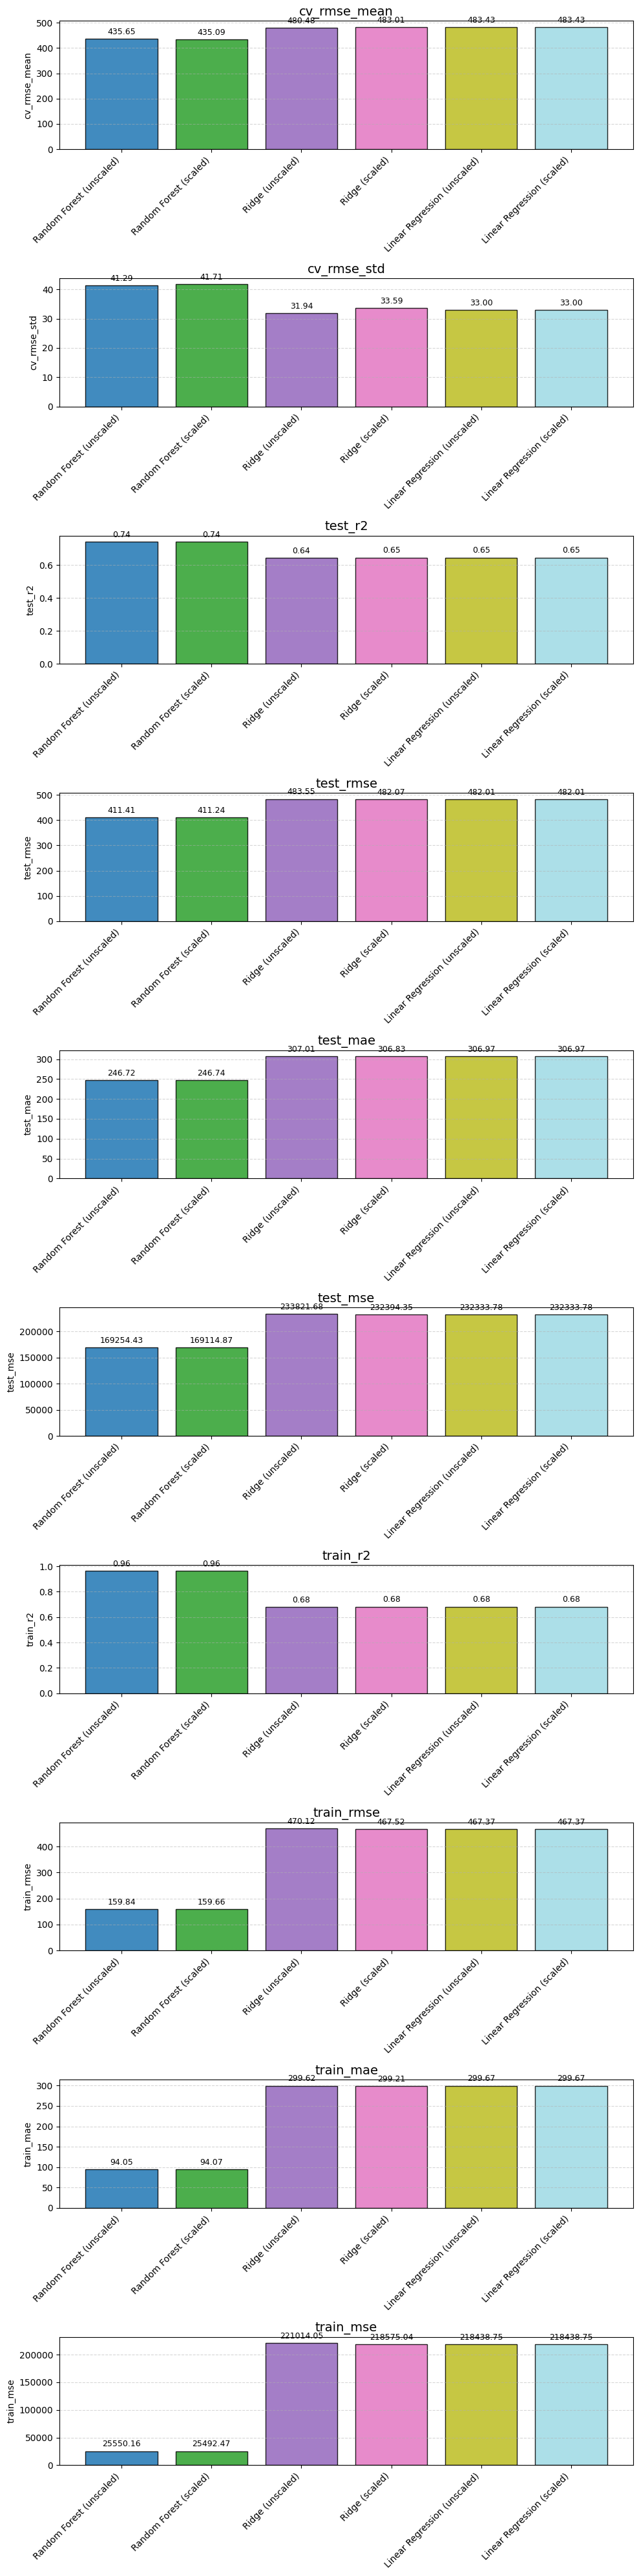

In [482]:
def plot_model_metrics(results_df, model_name_col="model", scaled_col="scaled"):
    """
    Plot all metrics for each model (scaled and unscaled) as grouped bar plots (vertical layout), with colors.
    """

    metrics = [
        "cv_rmse_mean",
        "cv_rmse_std",
        "test_r2",
        "test_rmse",
        "test_mae",
        "test_mse",
        "train_r2",
        "train_rmse",
        "train_mae",
        "train_mse",
    ]
    models = results_df[model_name_col].unique()
    n_metrics = len(metrics)
    fig, axes = plt.subplots(n_metrics, 1, figsize=(10, 4 * n_metrics), sharex=False)
    if n_metrics == 1:
        axes = [axes]

    # Create a color palette
    palette = cm.get_cmap("tab20", len(models) * 2)
    color_map = {}
    idx = 0
    for model in models:
        color_map[(model, False)] = palette(idx)
        idx += 1
        color_map[(model, True)] = palette(idx)
        idx += 1

    for i, metric in enumerate(metrics):
        ax = axes[i]
        bar_labels = []
        bar_values = []
        bar_colors = []
        for model in models:
            subset = results_df[results_df[model_name_col] == model]
            for scaled in [False, True]:
                val = subset[subset[scaled_col] == scaled][metric]
                if not val.empty:
                    label = f"{model} ({'scaled' if scaled else 'unscaled'})"
                    bar_labels.append(label)
                    bar_values.append(val.values[0])
                    bar_colors.append(color_map[(model, scaled)])
        bars = ax.bar(
            bar_labels, bar_values, color=bar_colors, alpha=0.85, edgecolor="black"
        )
        ax.set_title(metric, fontsize=14)
        ax.set_ylabel(metric)
        ax.set_xticklabels(bar_labels, rotation=45, ha="right")
        ax.grid(True, axis="y", linestyle="--", alpha=0.5)
        # Optionally, add value labels
        for bar in bars:
            height = bar.get_height()
            ax.annotate(
                f"{height:.2f}",
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3),
                textcoords="offset points",
                ha="center",
                va="bottom",
                fontsize=9,
            )
    plt.tight_layout()
    plt.show()


plot_model_metrics(all_results)

In [483]:
def plot_residuals_vs_targets(y_test, y_pred, title="Residuals vs Actual Price"):
    residuals = y_test - y_pred
    plt.figure(figsize=(8, 5))
    plt.scatter(y_test, residuals, alpha=0.5)
    plt.axhline(0, color="red", linestyle="--")
    plt.xlabel("Actual Price (y_test)")
    plt.ylabel("Residuals (y_test - y_pred)")
    plt.title(title)
    plt.tight_layout()
    plt.show()


def plot_actual_vs_predicted(y_test, y_pred, title="Actual vs Predicted Price"):
    plt.figure(figsize=(8, 5))
    plt.scatter(y_test, y_pred, alpha=0.5)
    plt.xlabel("Actual Price (y_test)")
    plt.ylabel("Predicted Price (y_pred)")
    plt.title(title)
    plt.plot(
        [y_test.min(), y_test.max()],
        [y_test.min(), y_test.max()],
        color="red",
        linestyle="--",
        label="Ideal Fit",
    )
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_result_analysis(
    scaled: bool,
    model_name: str,
    y_test: pd.Series,
    y_pred: pd.Series,
) -> None:
    """
    Plot the result analysis of the model.
    The function takes the following parameters:
    - scaled: whether the model is scaled or not
    - model_name: the name of the model
    - y_test: the test set
    - y_pred: the predicted values
    """
    if scaled:
        scaling = "scaled"
    else:
        scaling = "unscaled"

    plot_residuals_vs_targets(
        y_test, y_pred, title=f"Residuals vs Actual Price ({model_name} - {scaling})"
    )
    plot_actual_vs_predicted(
        y_test, y_pred, title=f"Actual vs Predicted Price ({model_name} - {scaling})"
    )

#### `RandomForestRegressor`

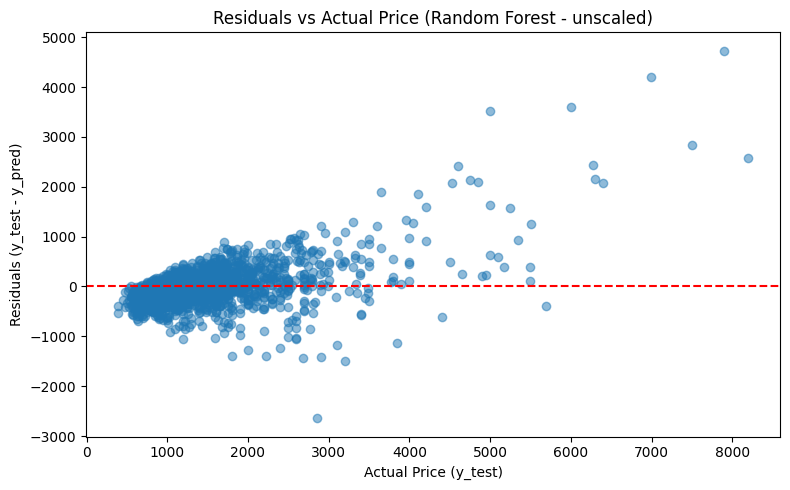

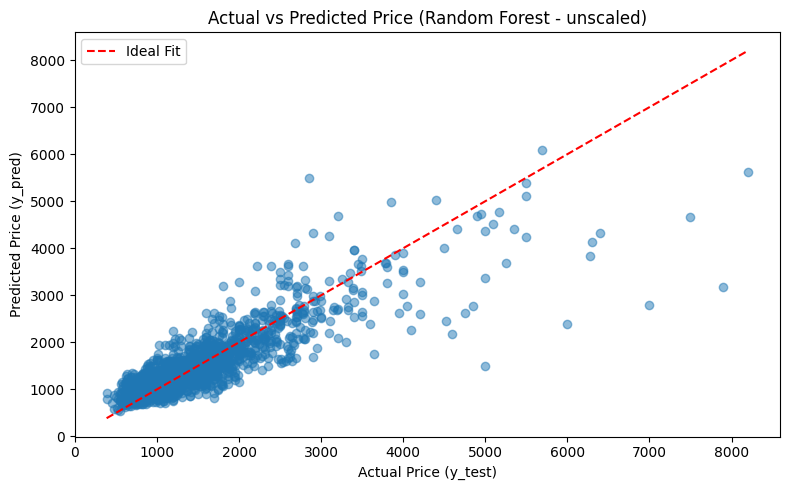

In [484]:
plot_result_analysis(
    scaled=False,
    model_name="Random Forest",
    y_test=y_test,
    y_pred=rfr.predict(X_test),
)

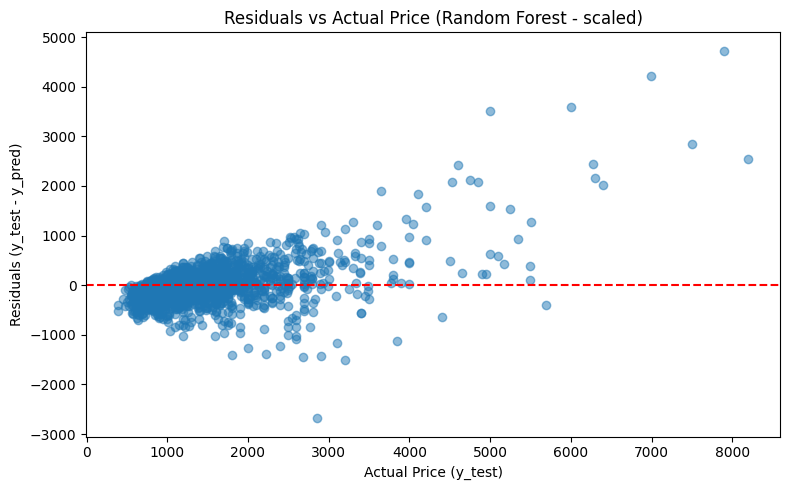

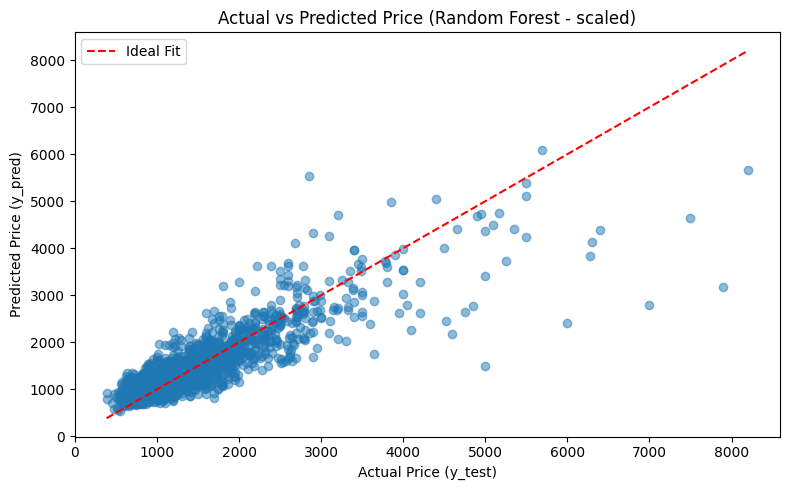

In [485]:
plot_result_analysis(
    scaled=True,
    model_name="Random Forest",
    y_test=y_test,
    y_pred=rfr_scaled.predict(X_test_scaled),
)

#### `Ridge`

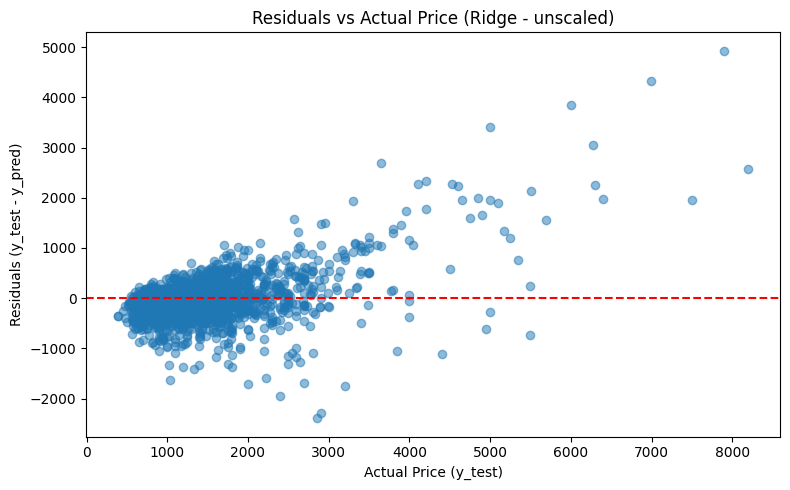

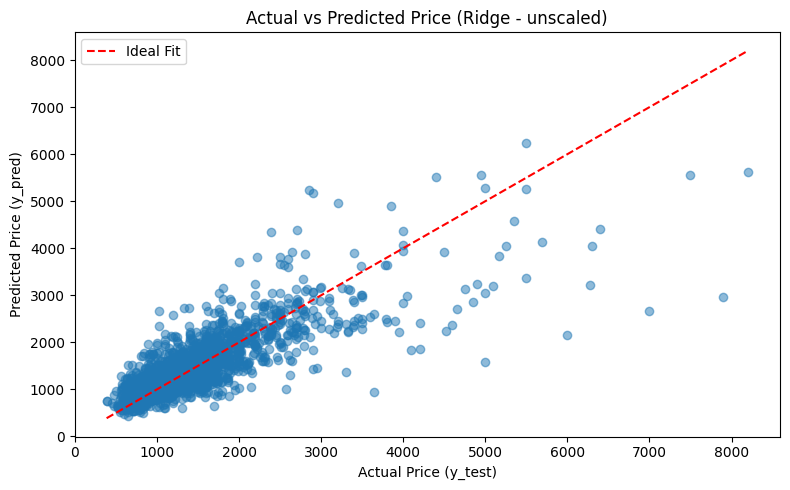

In [486]:
plot_result_analysis(
    scaled=False,
    model_name="Ridge",
    y_test=y_test,
    y_pred=ridge.predict(X_test),
)

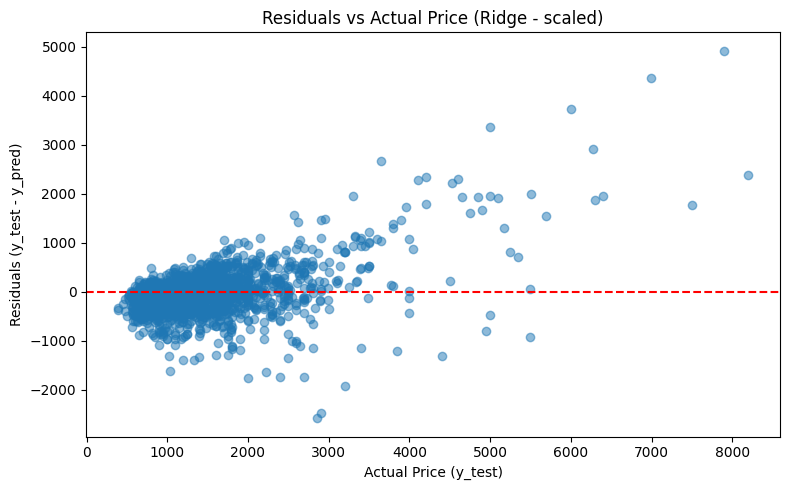

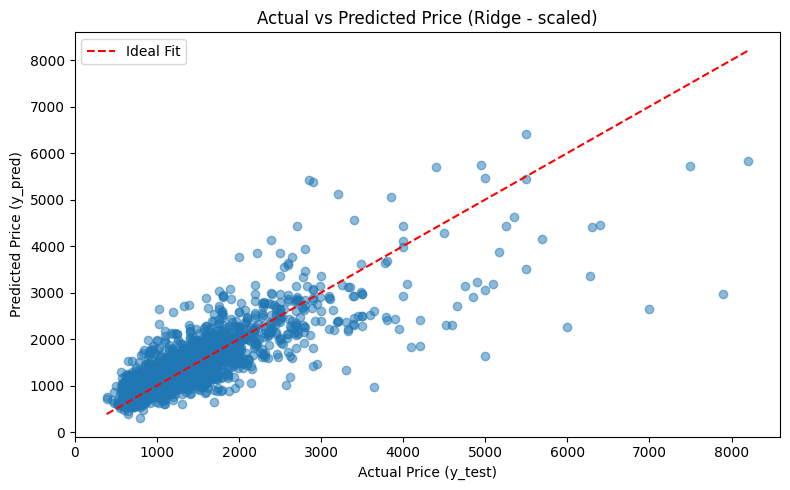

In [487]:
plot_result_analysis(
    scaled=True,
    model_name="Ridge",
    y_test=y_test,
    y_pred=ridge_scaled.predict(X_test_scaled),
)

#### `LinearRegression`

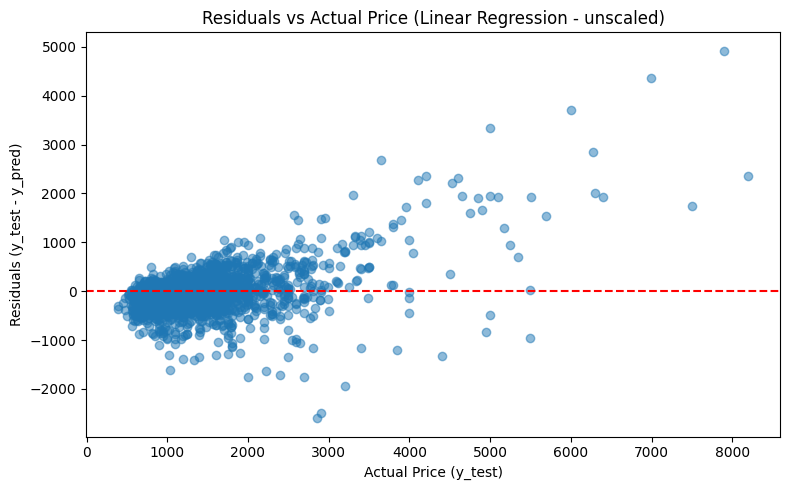

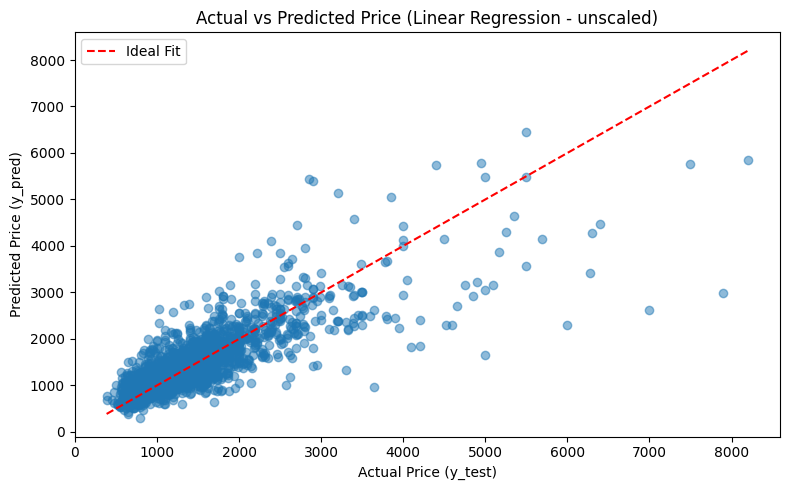

In [488]:
plot_result_analysis(
    scaled=False,
    model_name="Linear Regression",
    y_test=y_test,
    y_pred=lin.predict(X_test),
)

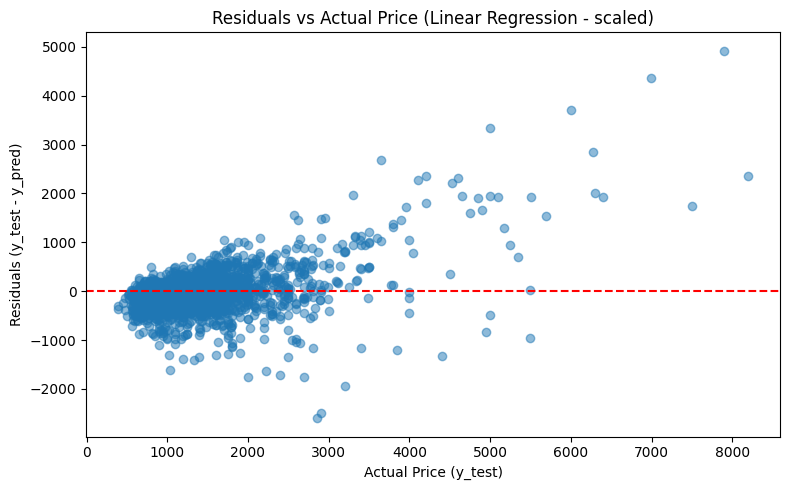

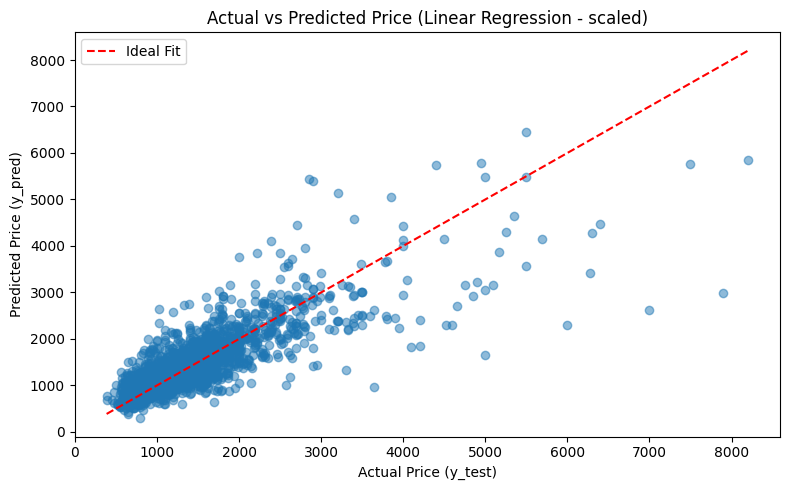

In [489]:
plot_result_analysis(
    scaled=True,
    model_name="Linear Regression",
    y_test=y_test,
    y_pred=lin_scaled.predict(X_test_scaled),
)

In [490]:
rent[TARGET].describe()

count    9576.000000
mean     1457.633563
std       824.932997
min       386.000000
25%       950.000000
50%      1269.000000
75%      1690.000000
max      9500.000000
Name: price, dtype: float64